<a href="https://colab.research.google.com/github/meghana2343/datascience/blob/main/GANs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**** GENERATIVE  MODELLING CASE STUDY: TYPES OF GANs****

STUDENT ID: 23070310

This is the second  assignment if module Advanced research module where  types of GANs are excuted

### Part 1 of GANs assignment ###

 part 1 includes of generating gans from the tutorial

In [ ]:
# Import packages.
import torch
from torch import nn
import math
import matplotlib.pyplot as plt

In [ ]:
# Setting a seed for reproducibility.
torch.manual_seed(42)

In [ ]:
train_data_length = 1024
train_data = torch.zeros((train_data_length, 2))

train_data[:, 0] = 2.0 * math.pi * torch.rand(train_data_length)
train_data[:, 1] = torch.sin(train_data[:, 0])

train_labels = torch.zeros(train_data_length)
train_set = [(train_data[i], train_labels[i]) for i in range(train_data_length)]

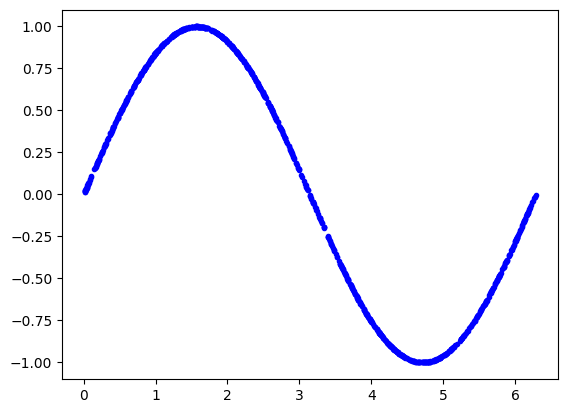

In [ ]:
# Plot the training data
plt.plot(train_data[:, 0], train_data[:, 1], ".", color="blue")
plt.show()

### Generate 2D Spiral Data

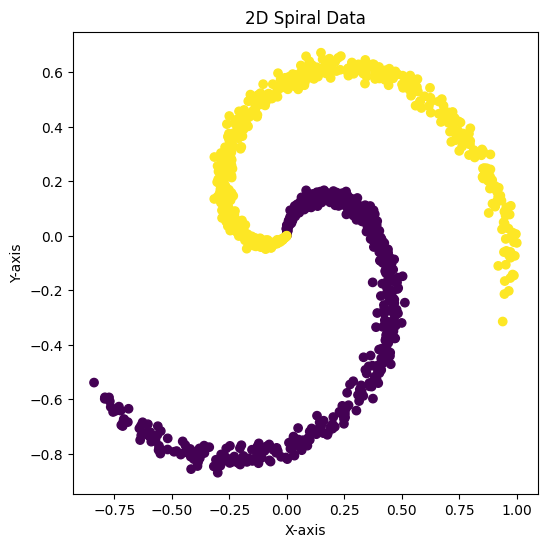

In [ ]:
import numpy as np

def generate_spiral_data(num_samples=1000, noise=0.1, n_classes=2):
    X = np.zeros((num_samples, 2))
    y = np.zeros(num_samples, dtype='uint8')

    for i in range(n_classes):
        ix = range(num_samples // n_classes * i, num_samples // n_classes * (i + 1))
        r = np.linspace(0.0, 1, num_samples // n_classes) # radius
        t = np.linspace(i * 4, (i + 1) * 4, num_samples // n_classes) + np.random.randn(num_samples // n_classes) * noise # theta
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        y[ix] = i

    spiral_data = torch.from_numpy(X).float()
    spiral_labels = torch.from_numpy(y).float()
    return spiral_data, spiral_labels

spiral_data, spiral_labels = generate_spiral_data()

plt.figure(figsize=(6,6))
plt.scatter(spiral_data[:, 0], spiral_data[:, 1], c=spiral_labels, cmap='viridis')
plt.title("2D Spiral Data")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()


### Generate Mixture of Gaussians Data

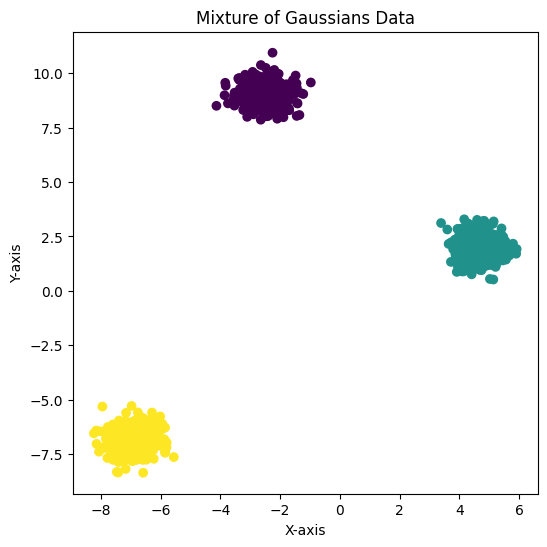

In [ ]:
from sklearn.datasets import make_blobs

def generate_gaussian_mixture_data(num_samples=1000, n_centers=3, cluster_std=0.5):
    X, y = make_blobs(n_samples=num_samples, centers=n_centers, cluster_std=cluster_std, random_state=42)
    gaussian_data = torch.from_numpy(X).float()
    gaussian_labels = torch.from_numpy(y).float()
    return gaussian_data, gaussian_labels

gaussian_data, gaussian_labels = generate_gaussian_mixture_data()

plt.figure(figsize=(6,6))
plt.scatter(gaussian_data[:, 0], gaussian_data[:, 1], c=gaussian_labels, cmap='viridis')
plt.title("Mixture of Gaussians Data")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()


### Generate Noisy Parametric Data ($y = sin(2x) + 0.3cos(5x) + \epsilon$)

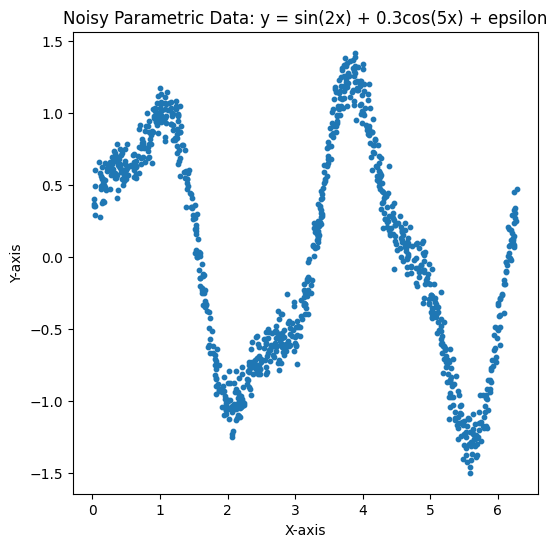

In [ ]:
def generate_noisy_parametric_data(num_samples=1000, noise_std=0.1):
    x = torch.rand(num_samples, 1) * 2 * math.pi
    y = torch.sin(2 * x) + 0.3 * torch.cos(5 * x) + torch.randn(num_samples, 1) * noise_std
    noisy_parametric_data = torch.cat((x, y), dim=1)
    return noisy_parametric_data

noisy_parametric_data = generate_noisy_parametric_data()

plt.figure(figsize=(6,6))
plt.scatter(noisy_parametric_data[:, 0], noisy_parametric_data[:, 1], s=10)
plt.title("Noisy Parametric Data: y = sin(2x) + 0.3cos(5x) + epsilon")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()


In [ ]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True
)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),  # activation function
            nn.Dropout(0.3),  # dropout to prevent overfitting
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid(),  # sigmoid activation to produce a probability
        )

    # Describe how the forward pass is calculated.
    def forward(self, x):
        output = self.model(x)
        return output

In [ ]:
# After declaring the discriminator class, we instantiate a discriminator object.
discriminator = Discriminator()
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x):
        output = self.model(x)
        return output


# Instantiate generator object.
generator = Generator()

In [ ]:
lr = 0.001
num_epochs = 2000
loss_function = nn.BCELoss()
optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):
        # Data for training the discriminator.
        real_samples_labels = torch.ones((batch_size, 1))
        latent_space_samples = torch.randn((batch_size, 2))
        generated_samples = generator(latent_space_samples)
        generated_samples_labels = torch.zeros((batch_size, 1))
        all_samples = torch.cat((real_samples, generated_samples))
        all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))

        # Training the discriminator.
        discriminator.zero_grad()
        output_discriminator = discriminator(all_samples)
        loss_discriminator = loss_function(output_discriminator, all_samples_labels)
        loss_discriminator.backward()
        optimizer_discriminator.step()

        # Data for training the generator.
        latent_space_samples = torch.randn((batch_size, 2))

        # Training the generator.
        generator.zero_grad()
        generated_samples = generator(latent_space_samples)
        output_discriminator_generated = discriminator(generated_samples)
        loss_generator = loss_function(
            output_discriminator_generated, real_samples_labels
        )
        loss_generator.backward()
        optimizer_generator.step()

        # Print loss at various training stages.
        print_epoch_num = (
            100  # Change this depending on often the loss should be printed.
        )
        if epoch % print_epoch_num == 0 and n == batch_size - 1:
            print(f"Epoch: {epoch} Loss D.: {loss_discriminator}")
            print(f"Epoch: {epoch} Loss G.: {loss_generator}")

Epoch: 0 Loss D.: 0.10501156747341156
Epoch: 0 Loss G.: 2.9276413917541504
Epoch: 100 Loss D.: 0.703309178352356
Epoch: 100 Loss G.: 0.696789562702179
Epoch: 200 Loss D.: 0.670529305934906
Epoch: 200 Loss G.: 0.7512572407722473
Epoch: 300 Loss D.: 0.6841614246368408
Epoch: 300 Loss G.: 0.7553582191467285
Epoch: 400 Loss D.: 0.661787748336792
Epoch: 400 Loss G.: 0.7027472853660583
Epoch: 500 Loss D.: 0.7167990207672119
Epoch: 500 Loss G.: 0.699663519859314
Epoch: 600 Loss D.: 0.6691504716873169
Epoch: 600 Loss G.: 0.7459690570831299
Epoch: 700 Loss D.: 0.7161340117454529
Epoch: 700 Loss G.: 0.6971224546432495
Epoch: 800 Loss D.: 0.6681060791015625
Epoch: 800 Loss G.: 0.9564664363861084
Epoch: 900 Loss D.: 0.7163175344467163
Epoch: 900 Loss G.: 0.6832739114761353
Epoch: 1000 Loss D.: 0.6924228668212891
Epoch: 1000 Loss G.: 0.7288417816162109
Epoch: 1100 Loss D.: 0.600561261177063
Epoch: 1100 Loss G.: 1.2107648849487305
Epoch: 1200 Loss D.: 0.703054666519165
Epoch: 1200 Loss G.: 0.6751221

In [ ]:
import torch

# Generate 1000 random 2D points and feed them to the generator.
latent_space_samples = torch.randn(1000, 2)
generated_samples = generator(latent_space_samples)

# Turn the PyTorch tensor into a NumPy array.
generated_samples_numpy = generated_samples.detach().numpy()

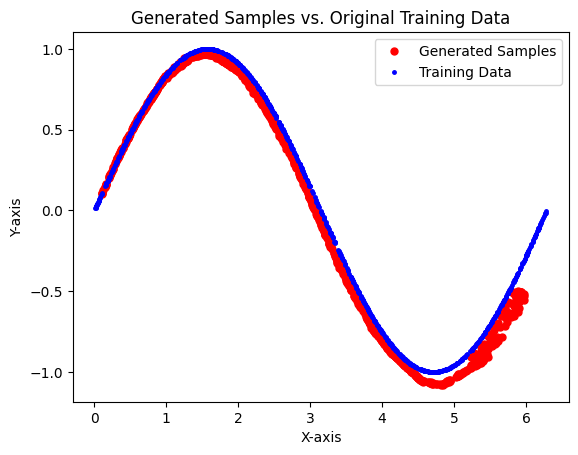

In [ ]:
# Plot the generated samples and the original training data.
plt.plot(
    generated_samples_numpy[:, 0], generated_samples_numpy[:, 1], ".", markersize=10,
    label="Generated Samples", color="red"
)
plt.plot(train_data[:, 0], train_data[:, 1], ".", markersize=5, label="Training Data", color="blue")
plt.title("Generated Samples vs. Original Training Data")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.show()

#### part 2 of the assignment

2.1: blood medmnist dataset

In [83]:
pip install medmnist torch torchvision matplotlib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.4 MB/s eta 0:00:00


In [84]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader

import medmnist
from medmnist import INFO

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import sqrtm

In [85]:
data_flag = 'bloodmnist'
info = INFO[data_flag]

DataClass = getattr(medmnist, info['python_class'])

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Loading the 64x64 pixel version of the dataset
train_dataset = DataClass(split='train', transform=transform, download=True, size=64)
test_dataset = DataClass(split='test', transform=transform, download=True, size=64)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

100%|██████████| 156M/156M [00:08<00:00, 18.6MB/s]


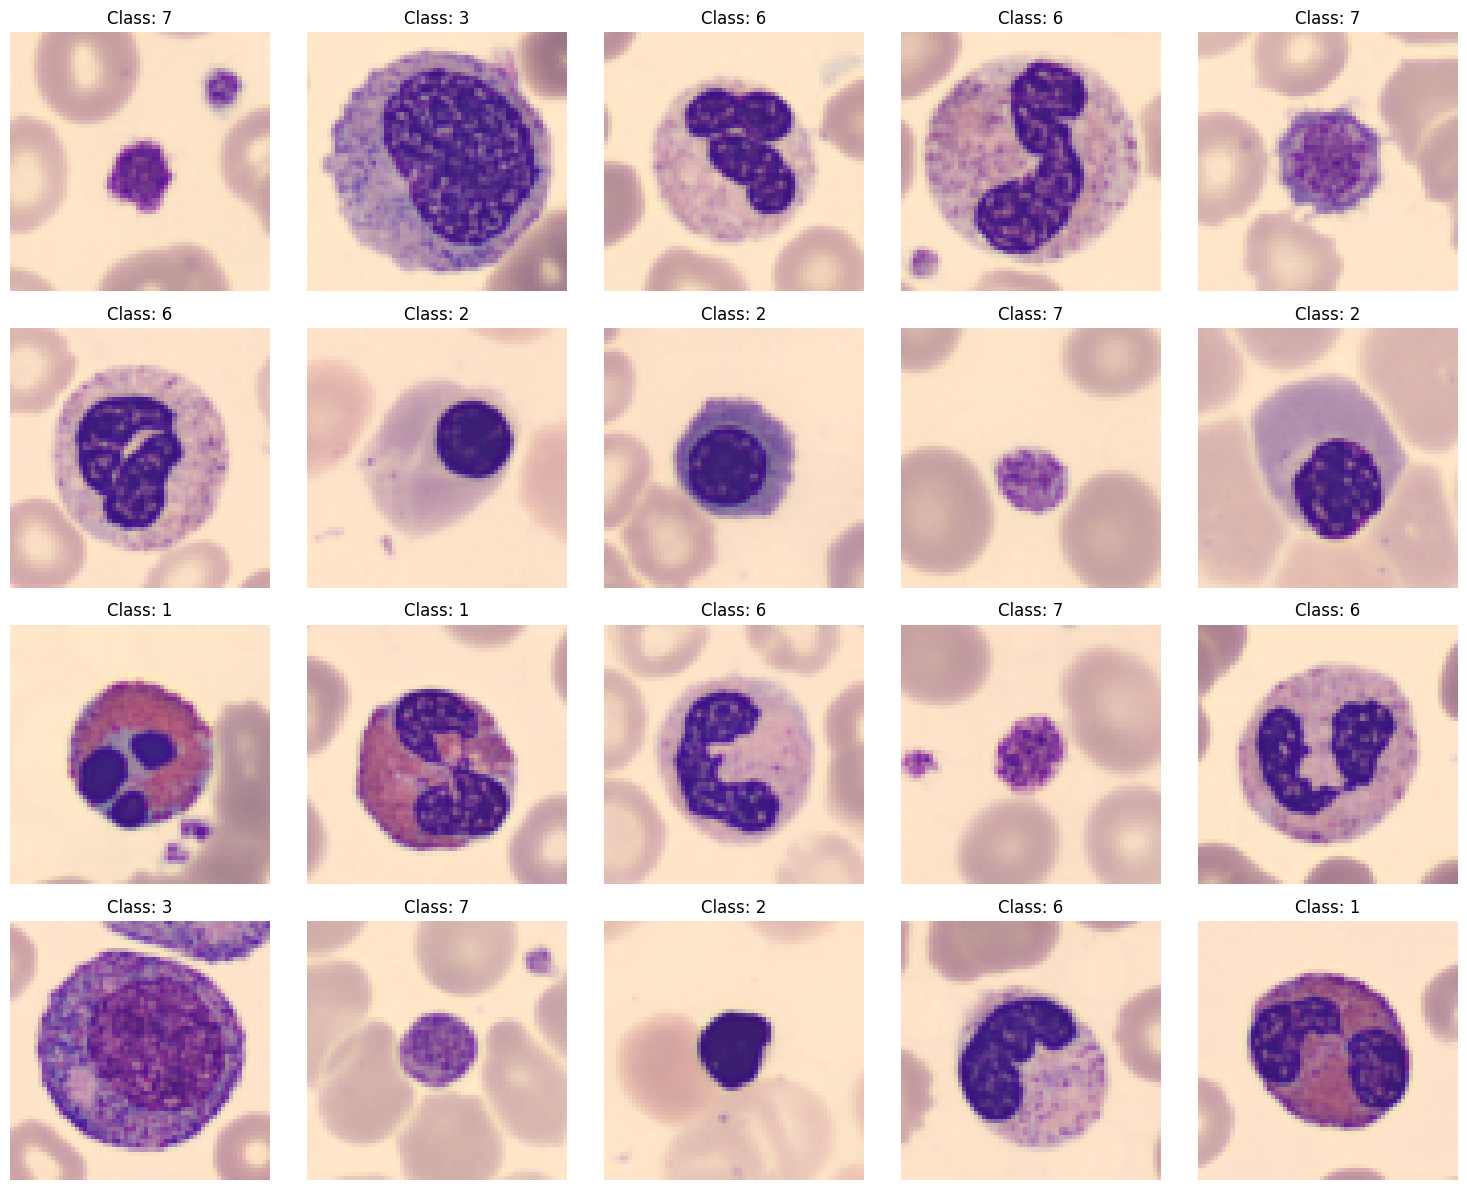

In [86]:
def show_samples(dataset):
    # Increased figure size and number of samples displayed (4 rows x 5 columns)
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    for i, ax in enumerate(axes.flatten()):
        if i >= len(dataset): # Ensure we don't go out of bounds for smaller datasets
            break
        img, label = dataset[i]
        # Permute the image dimensions from (C, H, W) to (H, W, C)
        img = img.permute(1, 2, 0)
        # Denormalize image pixel values from [-1, 1] to [0, 1] for display
        img = img * 0.5 + 0.5
        # Use 'nearest' interpolation for sharper display of low-res images
        ax.imshow(img, interpolation='nearest')
        # Extract the scalar value from the label tensor for display
        ax.set_title(f"Class: {label.item()}")
        ax.axis('off')
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

show_samples(train_dataset)

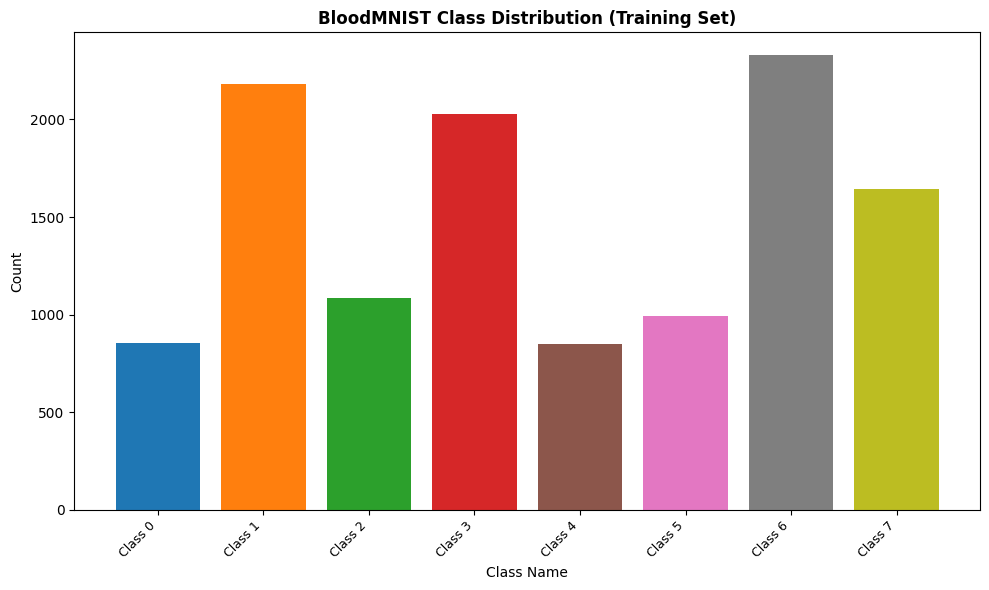

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import medmnist # Ensure medmnist is imported for INFO

# Get info for bloodmnist (although n_classes is derived differently now)
data_flag = 'bloodmnist'
info = medmnist.INFO[data_flag]

labels = [label.item() for _, label in train_dataset] # .item() to convert tensor to scalar
unique_labels, counts = np.unique(labels, return_counts=True)
n_classes = len(unique_labels) # Get the number of classes from the unique labels
class_names = [f'Class {i}' for i in range(n_classes)] # Generate generic class names


fig, ax = plt.subplots(figsize=(10, 6)) # Create a figure and a single subplot

ax.bar(range(len(class_names)),
       counts, # Use the calculated counts for the bars
       color=plt.cm.tab10(np.arange(len(class_names)) / len(class_names)))
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax.set_title('BloodMNIST Class Distribution (Training Set)', fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Class Name') # Added explicit x-label
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [96]:
class MedMNISTGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            # Input: (latent_dim, 1, 1)
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False), # Output: (512, 4, 4)
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False), # Output: (256, 8, 8)
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False), # Output: (128, 16, 16)
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), # Output: (64, 32, 32)
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False), # Output: (3, 64, 64)
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

In [97]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128*16*16, 1), # Corrected in_features to 32768 (128 channels * 16x16 spatial output)
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [98]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 100
G = MedMNISTGenerator(latent_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [99]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 100
my_generator = MedMNISTGenerator(latent_dim).to(device)
print(f"Generator instance created: {my_generator}")

Generator instance created: MedMNISTGenerator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), 

In [100]:
num_epochs = 30

g_losses, d_losses = [], []

for epoch in range(num_epochs):
    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device)

        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # --- Train Discriminator ---
        z = torch.randn(batch_size, latent_dim, 1, 1).to(device)
        fake_imgs = G(z)

        real_loss = criterion(D(real_imgs), real_labels)
        fake_loss = criterion(D(fake_imgs.detach()), fake_labels)

        d_loss = real_loss + fake_loss

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # --- Train Generator ---
        output = D(fake_imgs)
        g_loss = criterion(output, real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    print(f"Epoch [{epoch}/{num_epochs}] D Loss: {d_loss:.4f} G Loss: {g_loss:.4f}")

Epoch [0/30] D Loss: 1.4626 G Loss: 1.5885
Epoch [1/30] D Loss: 1.3267 G Loss: 0.6815
Epoch [2/30] D Loss: 1.9612 G Loss: 1.2834
Epoch [3/30] D Loss: 1.2588 G Loss: 1.1338
Epoch [4/30] D Loss: 1.4742 G Loss: 4.7920
Epoch [5/30] D Loss: 0.5386 G Loss: 2.7622
Epoch [6/30] D Loss: 0.6887 G Loss: 1.9630
Epoch [7/30] D Loss: 0.4304 G Loss: 2.2293
Epoch [8/30] D Loss: 1.2965 G Loss: 0.9178
Epoch [9/30] D Loss: 1.5714 G Loss: 0.9512
Epoch [10/30] D Loss: 0.8483 G Loss: 1.2758
Epoch [11/30] D Loss: 0.8681 G Loss: 1.0533
Epoch [12/30] D Loss: 1.1576 G Loss: 4.6189
Epoch [13/30] D Loss: 1.1411 G Loss: 0.9356
Epoch [14/30] D Loss: 1.2465 G Loss: 0.7332
Epoch [15/30] D Loss: 1.1049 G Loss: 0.7406
Epoch [16/30] D Loss: 1.2357 G Loss: 0.8361
Epoch [17/30] D Loss: 1.1633 G Loss: 2.8103
Epoch [18/30] D Loss: 1.0632 G Loss: 2.5853
Epoch [19/30] D Loss: 0.9686 G Loss: 0.8495
Epoch [20/30] D Loss: 1.4241 G Loss: 0.6656
Epoch [21/30] D Loss: 1.2122 G Loss: 0.5329
Epoch [22/30] D Loss: 0.8616 G Loss: 1.991

### Visual Comparison: Real vs. Generated BloodMNIST Images

In [ ]:
def show_generated_samples(generator, n=10):
    generator.eval()
    z = torch.randn(n, latent_dim, 1, 1).to(device)
    fake_imgs = generator(z).detach().cpu()

    fig, axes = plt.subplots(1, n, figsize=(15, 2))
    for i in range(n):
        img = fake_imgs[i].squeeze().permute(1, 2, 0) # Permute back to (H, W, C)
        img = (img + 1) / 2 # Denormalize from [-1, 1] to [0, 1]
        axes[i].imshow(img)
        axes[i].axis('off')
    plt.suptitle('Generated BloodMNIST Samples', y=1.1, fontsize=14)
    plt.show()

def show_real_samples(dataset, n=10):
    fig, axes = plt.subplots(1, n, figsize=(15, 2))
    for i in range(n):
        img, _ = dataset[i]
        img = img.squeeze().permute(1, 2, 0) # Permute back to (H, W, C)
        img = (img + 1) / 2 # Denormalize from [-1, 1] to [0, 1]
        axes[i].imshow(img)
        axes[i].axis('off')
    plt.suptitle('Real BloodMNIST Samples', y=1.1, fontsize=14)
    plt.show()

print("Real BloodMNIST Samples:")
show_real_samples(train_dataset, n=10)

print("Generated BloodMNIST Samples:")
try:
    show_generated_samples(G, n=10)
except NameError as e:
    if "name 'G' is not defined" in str(e):
        print("Error: The generator model 'G' is not defined. Please ensure you have run the cells that define and train the 'MedMNISTGenerator' (G), specifically cells '2a_0ZpJMHEWY' and 'HUwgnRtPHGb-'.")
    else:
        raise

### Discussion on BloodMNIST GAN Performance

**Visual Quality:**
*   Observe the generated images. Do they resemble actual blood cells? Are the shapes and colors plausible?
*   Look for common GAN issues like mode collapse (generating only a few types of images) or image artifacts.

**FID Score Interpretation:**
*   The Fréchet Inception Distance (FID) measures the similarity between the distributions of real and generated images. A lower FID score indicates better quality and diversity of generated images.
*   Compare the FID score obtained for BloodMNIST with typical scores for similar tasks (e.g., MNIST generation usually has very low FID, while more complex datasets have higher scores).
*   A high FID score suggests that the generator has not fully learned the underlying data distribution, leading to synthetic images that are statistically different from real ones.

**Reflections on Quality:**
*   Based on the visual comparison and the FID score, how well did the DCGAN perform on the BloodMNIST dataset?
*   What are the strengths and weaknesses of the generated data?
*   What potential improvements could be made to enhance the generation quality (e.g., more training epochs, hyperparameter tuning, different GAN architectures like WGAN-GP, or conditional GANs for better control over generated classes)?

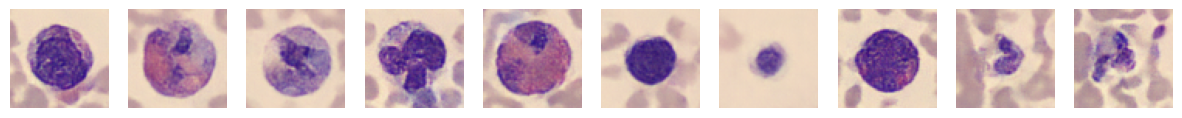

In [ ]:
def generate_images(G, n=10):
    G.eval()
    z = torch.randn(n, latent_dim, 1, 1).to(device)
    fake = G(z).detach().cpu()

    fig, axes = plt.subplots(1, n, figsize=(15,2))
    for i in range(n):
        # Denormalize pixel values from [-1, 1] to [0, 1] and permute dimensions
        img = fake[i].squeeze().permute(1, 2, 0)
        img = (img + 1) / 2 # Denormalization step
        axes[i].imshow(img)
        axes[i].axis('off')
    plt.show()

generate_images(G)

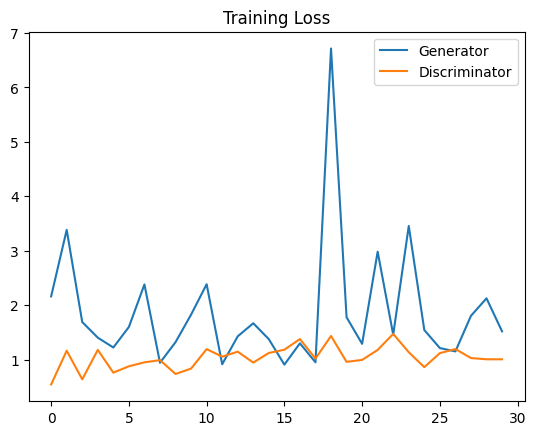

In [ ]:
plt.plot(g_losses, label="Generator")
plt.plot(d_losses, label="Discriminator")
plt.legend()
plt.title("Training Loss")
plt.show()

In [ ]:
def calculate_fid(real, fake):
    mu1, sigma1 = real.mean(axis=0), np.cov(real, rowvar=False)
    mu2, sigma2 = fake.mean(axis=0), np.cov(fake, rowvar=False)

    diff = mu1 - mu2
    covmean = sqrtm(sigma1.dot(sigma2))

    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2*covmean)
    return np.real(fid)

In [ ]:
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim, num_classes):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.net = nn.Sequential(
            # Input: (latent_dim + num_classes, 1, 1)
            nn.ConvTranspose2d(latent_dim + num_classes, 512, 4, 1, 0, bias=False), # Output: (512, 4, 4)
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False), # Output: (256, 8, 8)
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False), # Output: (128, 16, 16)
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), # Output: (64, 32, 32)
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False), # Output: (3, 64, 64)
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_input = self.label_emb(labels).unsqueeze(2).unsqueeze(3)
        x = torch.cat([z, label_input], dim=1)
        return self.net(x)

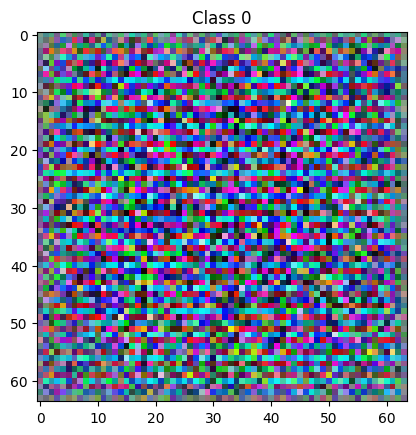

In [ ]:
def generate_class(G, class_id):
    z = torch.randn(1, latent_dim, 1, 1).to(device)
    label = torch.tensor([class_id]).to(device)

    img = G(z, label).detach().cpu()
    # Denormalize pixel values from [-1, 1] to [0, 1] and permute dimensions
    img = img.squeeze().permute(1, 2, 0)
    img = (img + 1) / 2 # Denormalization step
    plt.imshow(img)
    plt.title(f"Class {class_id}")
    plt.show()

# Generate a plot for class 0 as an example
generate_class(ConditionalGenerator(latent_dim, num_classes=8).to(device), 0)

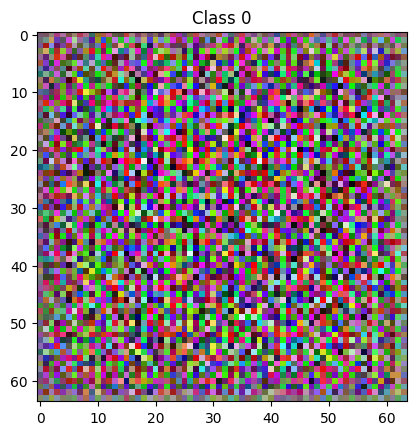

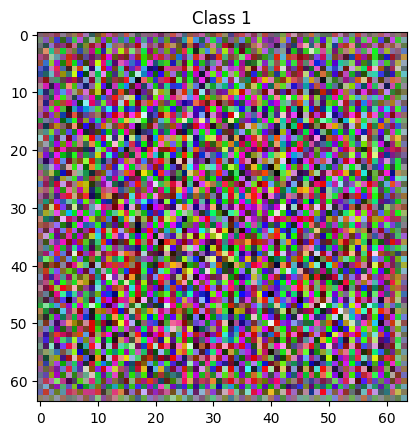

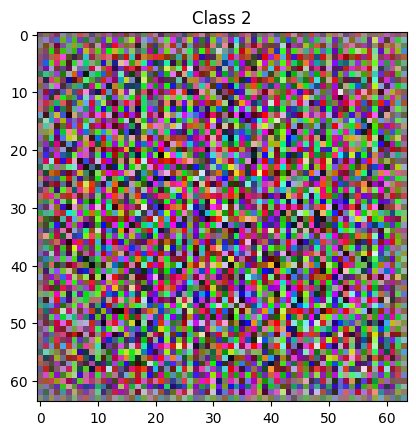

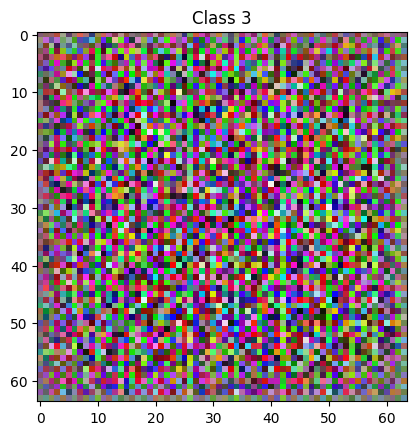

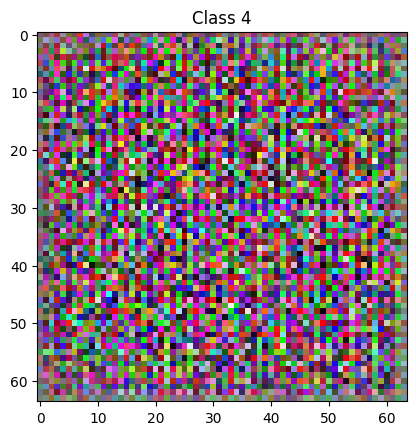

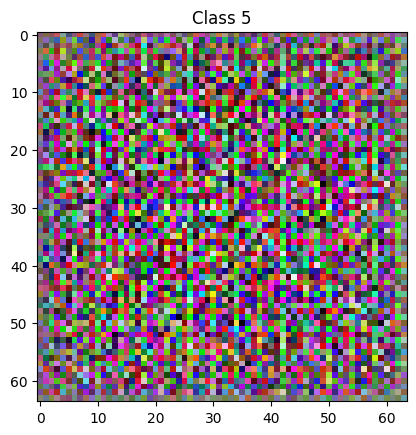

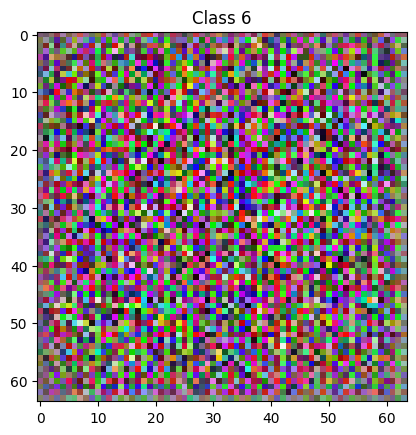

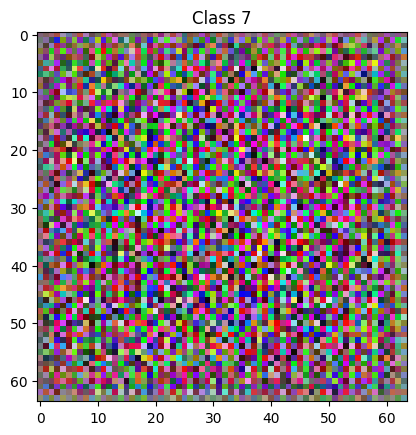

In [ ]:
# Instantiate the ConditionalGenerator once
num_classes = 8
conditional_generator = ConditionalGenerator(latent_dim, num_classes).to(device)

# Generate and display an image for each class
for i in range(num_classes):
    generate_class(conditional_generator, i)

#### 2.2 Part 2.2: Cybersecurity – Synthetic Traffic with CICIDS 2017

Shape: (80389, 79)

Label distribution:
Label
BENIGN              63627
DoS slowloris        5796
DoS Slowhttptest     5499
DoS Hulk             5466
Name: count, dtype: int64
Rows after filtering: 80388
Label
BENIGN              63627
DoS slowloris        5796
DoS Slowhttptest     5499
DoS Hulk             5466
Name: count, dtype: int64

Feature dimensions : 78
Class balance       : 63627 BENIGN | 16761 DoS


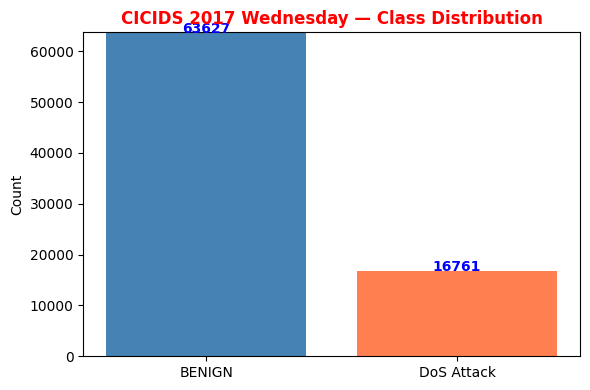

In [82]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

FILE_PATH = '/content/Wednesday-workingHours.pcap_ISCX.csv'

# ── Load the dataset
df = pd.read_csv(FILE_PATH, low_memory=False)
df.columns = df.columns.str.strip()

print(f'Shape: {df.shape}')
print(f'\nLabel distribution:')
print(df['Label'].value_counts())


# Preprocess CICIDS


def preprocess_cicids(df: pd.DataFrame):

    # Keep BENIGN and any row whose label contains 'DoS'
    mask = df['Label'].str.contains('BENIGN|DoS', case=False, na=False)
    df   = df[mask].copy()
    print(f'Rows after filtering: {len(df)}')
    print(df['Label'].value_counts())

    # Extract labels
    y = (df['Label'] != 'BENIGN').astype(int).values
    # Drop non-feature columns
    drop_cols = ['Label', 'Flow ID', ' Source IP', ' Source Port',
                 ' Destination IP', ' Destination Port', ' Timestamp']
    drop_cols = [c for c in drop_cols if c in df.columns]
    X = df.drop(columns=drop_cols)

    # Keep only numeric columns
    X = X.select_dtypes(include=[np.number])

    # Replace Inf and NaN
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)

    feature_names = X.columns.tolist()

    # Standardise
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)

    return X_scaled, y, feature_names


X_cicids, y_cicids, feature_names = preprocess_cicids(df)
N_FEATURES = X_cicids.shape[1]
print(f'\nFeature dimensions : {N_FEATURES}')
print(f'Class balance       : {(y_cicids==0).sum()} BENIGN | {(y_cicids==1).sum()} DoS')

# Class distribution plot
fig, ax = plt.subplots(figsize=(6, 4))
classes, counts = np.unique(y_cicids, return_counts=True)
ax.bar(['BENIGN', 'DoS Attack'], counts, color=['steelblue', 'coral'])
ax.set_title('CICIDS 2017 Wednesday — Class Distribution', fontweight='bold', color="red")
ax.set_ylabel('Count')
for i, v in enumerate(counts):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold', color="blue")
ax.set_ylim(0, max(counts) + 100)
plt.tight_layout()
plt.savefig('cicids_class_dist.png', dpi=150)
plt.show()

In [60]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np # Ensure numpy is imported for type hinting in train_tabular_gan

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Define DEVICE for compatibility with user's provided code that uses DEVICE
DEVICE = device

class TabularGenerator(nn.Module):


    def __init__(self, noise_dim: int = 64, output_dim: int = 78):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 512),       nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, z):
        return self.net(z)


class TabularDiscriminator(nn.Module):

    def __init__(self, input_dim: int = 78):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256, 512),       nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(512, 256),       nn.LeakyReLU(0.2),
            nn.Linear(256, 1),         nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


def train_tabular_gan(
    X: np.ndarray,
    noise_dim:  int   = 64,
    n_epochs:   int   = 200,
    batch_size: int   = 512,
    lr:         float = 1e-4,
    device=DEVICE
):

    n_feats = X.shape[1]
    G = TabularGenerator(noise_dim=noise_dim, output_dim=n_feats).to(device)
    D = TabularDiscriminator(input_dim=n_feats).to(device)

    opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    loader = DataLoader(
        TensorDataset(torch.from_numpy(X)),
        batch_size=batch_size, shuffle=True, drop_last=True
    )

    g_losses, d_losses = [], []

    for epoch in range(1, n_epochs + 1):
        g_ep, d_ep, n_b = 0.0, 0.0, 0

        for (real_batch,) in loader:
            real_batch = real_batch.to(device)
            bs = real_batch.size(0)

            # Labels smoothed for discriminator training
            real_labels = torch.ones(bs,  1, device=device) * 0.9
            fake_labels = torch.zeros(bs, 1, device=device)

            # Train D
            opt_D.zero_grad()
            d_real = criterion(D(real_batch), real_labels)
            z = torch.randn(bs, noise_dim, device=device)
            d_fake = criterion(D(G(z).detach()), fake_labels)
            d_loss = (d_real + d_fake) / 2
            d_loss.backward(); opt_D.step()

            # Train G
            opt_G.zero_grad()
            z = torch.randn(bs, noise_dim, device=device)
            g_loss = criterion(D(G(z)), real_labels)
            g_loss.backward(); opt_G.step()

            g_ep += g_loss.item(); d_ep += d_loss.item(); n_b += 1

        g_losses.append(g_ep / n_b)
        d_losses.append(d_ep / n_b)

        if epoch % 50 == 0:
            print(f'Epoch {epoch:4d}/{n_epochs} | G: {g_losses[-1]:.4f} | D: {d_losses[-1]:.4f}')

    return G, g_losses, d_losses


print('Training Tabular GAN on CICIDS traffic...')
G_cicids, g_loss_cic, d_loss_cic = train_tabular_gan(
    X=X_cicids, noise_dim=64, n_epochs=300, batch_size=512, lr=1e-4
)

Training Tabular GAN on CICIDS traffic...
Epoch   50/300 | G: 1.3798 | D: 0.5124
Epoch  100/300 | G: 1.7066 | D: 0.4586
Epoch  150/300 | G: 2.0179 | D: 0.4177
Epoch  200/300 | G: 2.1851 | D: 0.3918
Epoch  250/300 | G: 2.2768 | D: 0.3816
Epoch  300/300 | G: 2.2930 | D: 0.3833


Starting GAN training for synthetic traffic data...
Epoch [0/1000] Loss_D: 0.7775 Loss_G: 1.8202
Epoch [100/1000] Loss_D: 0.5416 Loss_G: 2.5034
Epoch [200/1000] Loss_D: 0.5476 Loss_G: 2.7834
Epoch [300/1000] Loss_D: 0.5470 Loss_G: 2.2109
Epoch [400/1000] Loss_D: 0.4945 Loss_G: 2.1820
Epoch [500/1000] Loss_D: 0.3773 Loss_G: 2.6458
Epoch [600/1000] Loss_D: 0.5739 Loss_G: 2.4279
Epoch [700/1000] Loss_D: 0.4823 Loss_G: 2.2130
Epoch [800/1000] Loss_D: 0.5513 Loss_G: 2.2282
Epoch [900/1000] Loss_D: 0.4414 Loss_G: 2.3707
Epoch [999/1000] Loss_D: 0.4928 Loss_G: 1.9084
GAN training for synthetic traffic data complete!


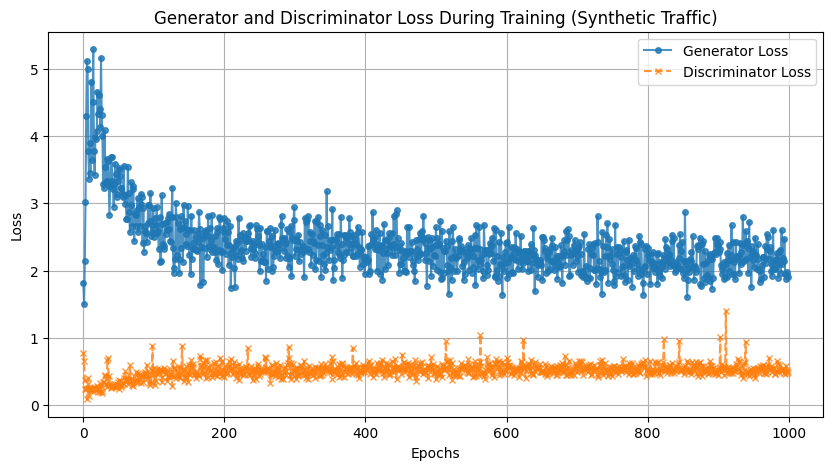

In [55]:
# Training Loop for Tabular GAN
g_losses_traffic, d_losses_traffic = [], []

# Convert X_tensor to TensorDataset and DataLoader
traffic_dataset = torch.utils.data.TensorDataset(X_tensor)
traffic_dataloader = torch.utils.data.DataLoader(traffic_dataset, batch_size=batch_size, shuffle=True)

print("Starting GAN training for synthetic traffic data...")
for epoch in range(num_epochs):
    for i, (real_samples,) in enumerate(traffic_dataloader):
        real_samples = real_samples.to(device)
        b_size = real_samples.size(0)

        # Create labels for real and fake images
        real_labels = torch.ones(b_size, 1).to(device)
        fake_labels = torch.zeros(b_size, 1).to(device)

        # --- Train Discriminator ---
        D_traffic.zero_grad()

        # Train with real samples
        output_real = D_traffic(real_samples)
        errD_real = criterion(output_real, real_labels)
        errD_real.backward()

        # Train with fake samples
        noise = torch.randn(b_size, latent_dim).to(device)
        fake_samples = G_traffic(noise)
        output_fake = D_traffic(fake_samples.detach())
        errD_fake = criterion(output_fake, fake_labels)
        errD_fake.backward()

        errD = errD_real + errD_fake
        optimizer_D_traffic.step()

        # --- Train Generator ---
        G_traffic.zero_grad()
        output_gen = D_traffic(fake_samples)
        errG = criterion(output_gen, real_labels) # Generator wants fake samples to be classified as real
        errG.backward()
        optimizer_G_traffic.step()

    # Save Losses for plotting later
    g_losses_traffic.append(errG.item())
    d_losses_traffic.append(errD.item())

    # Output training stats
    if epoch % 100 == 0 or epoch == num_epochs - 1:
        print(f'Epoch [{epoch}/{num_epochs}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f}')

print("GAN training for synthetic traffic data complete!")

# Plot the training losses
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training (Synthetic Traffic)")
plt.plot(g_losses_traffic, label="Generator Loss", linestyle='-', marker='o', markersize=4, alpha=0.8)
plt.plot(d_losses_traffic, label="Discriminator Loss", linestyle='--', marker='x', markersize=4, alpha=0.8)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Evaluation of Synthetic Data Alignment (PCA Results)

In [63]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch
import random
import seaborn as sns


SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


# Generate Fake Samples

N_SAMPLES = 3000
LATENT_DIM = 64

G_cicids.eval()

with torch.no_grad():
    noise = torch.randn(N_SAMPLES, LATENT_DIM).to(DEVICE)
    fake_data = G_cicids(noise).cpu().numpy()

# Select same number of real samples
real_indices = np.random.choice(len(X_cicids), N_SAMPLES, replace=False)
real_data = X_cicids[real_indices]

print("Real Data Shape:", real_data.shape)
print("Fake Data Shape:", fake_data.shape)

Real Data Shape: (3000, 78)
Fake Data Shape: (3000, 78)


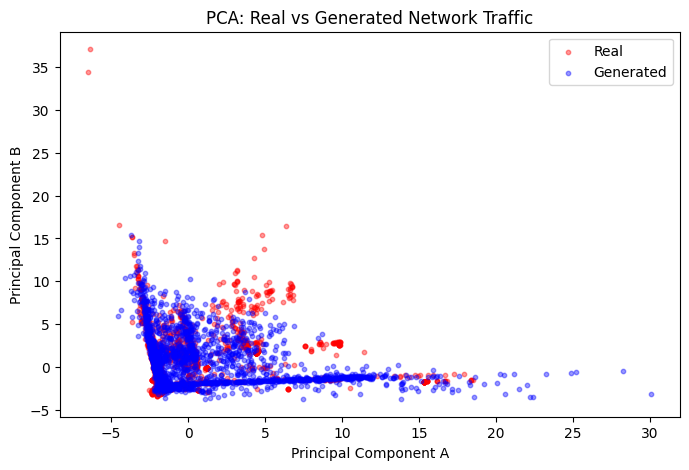

In [71]:
combined_data = np.vstack([real_data, fake_data])

pca = PCA(n_components=2, random_state=SEED)
pca_result = pca.fit_transform(combined_data)

real_pca = pca_result[:N_SAMPLES]
fake_pca = pca_result[N_SAMPLES:]

plt.figure(figsize=(8,5))

plt.scatter(real_pca[:,0], real_pca[:,1],
            alpha=0.4, s=10, label="Real", color="red")

plt.scatter(fake_pca[:,0], fake_pca[:,1],
            alpha=0.4, s=10, label="Generated", color="blue")

plt.title("PCA: Real vs Generated Network Traffic")
plt.xlabel("Principal Component A")
plt.ylabel("Principal Component B")
plt.legend()
plt.show()

Running t-SNE...


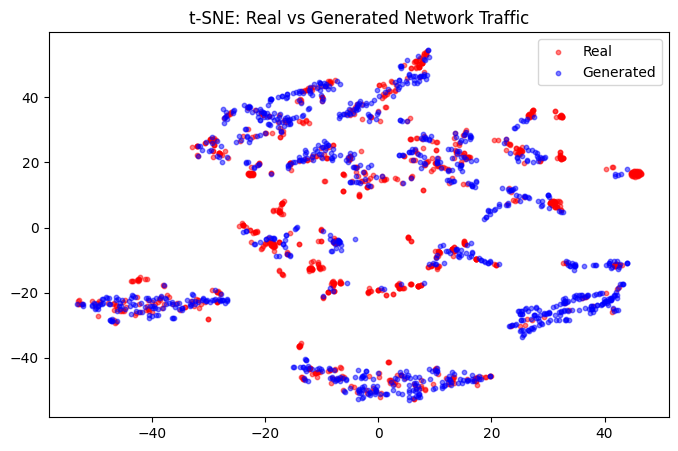

In [72]:
print("Running t-SNE...")

TSNE_SAMPLES = 1000

tsne_input = np.vstack([
    real_data[:TSNE_SAMPLES],
    fake_data[:TSNE_SAMPLES]
])

tsne = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=30
)

tsne_result = tsne.fit_transform(tsne_input)

real_tsne = tsne_result[:TSNE_SAMPLES]
fake_tsne = tsne_result[TSNE_SAMPLES:]

plt.figure(figsize=(8,5))

plt.scatter(real_tsne[:,0], real_tsne[:,1],
            alpha=0.5, s=10, label="Real",color="red")

plt.scatter(fake_tsne[:,0], fake_tsne[:,1],
            alpha=0.5, s=10, label="Generated", color="blue")

plt.title("t-SNE: Real vs Generated Network Traffic")
plt.legend()
plt.show()

### Quantitative Evaluation: Mean Squared Error (MSE) of Feature Means



In [75]:
real_data_mean = np.mean(real_data, axis=0)
fake_data_mean = np.mean(fake_data, axis=0)

mse = np.mean((real_data_mean - fake_data_mean)**2)

print(f"Mean Squared Error between real and synthetic feature means: {mse:.4f}")

Mean Squared Error between real and synthetic feature means: 0.0222


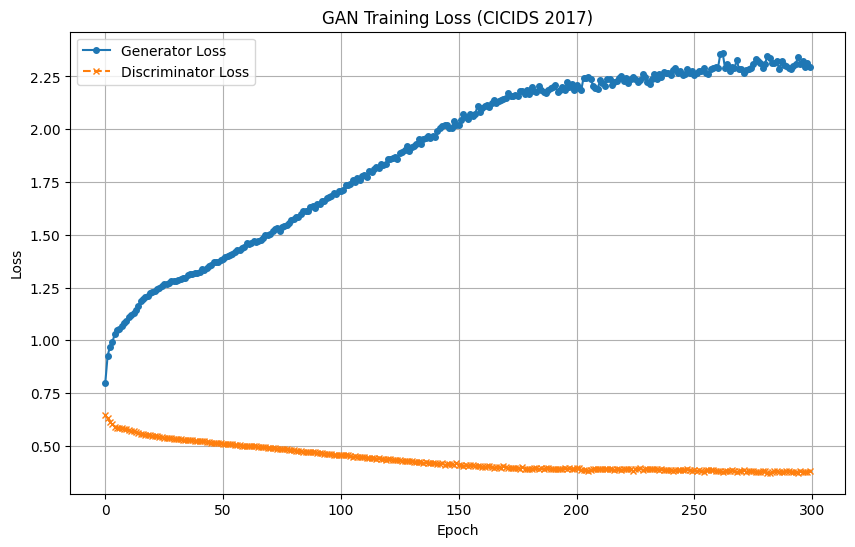

In [74]:
plt.figure(figsize=(10,6))

plt.plot(g_loss_cic, label="Generator Loss", linestyle='-', marker='o', markersize=4)
plt.plot(d_loss_cic, label="Discriminator Loss", linestyle='--', marker='x', markersize=4)

plt.title("GAN Training Loss (CICIDS 2017)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True) # Added grid for readability
plt.show()

have to do all the days for extra credit

### Extending to Full CICIDS 2017 Dataset (All Days)



In [76]:
from sklearn.preprocessing import LabelEncoder

# Define the base path for CICIDS 2017 files (assuming they are in /content/)
# We'll include all days if available. Adjust paths if necessary.
CICIDS_FILE_PATHS = [
    '/content/Monday-workingHours.pcap_ISCX.csv',
    '/content/Tuesday-workingHours.pcap_ISCX.csv',
    '/content/Wednesday-workingHours.pcap_ISCX.csv',
    '/content/Thursday-workingHours.pcap_ISCX.csv',
    '/content/Friday-workingHours.pcap_ISCX.csv'
]

# Load all CICIDS 2017 files and concatenate them
full_df_list = []
for file_path in CICIDS_FILE_PATHS:
    if os.path.exists(file_path):
        df_day = pd.read_csv(file_path, low_memory=False)
        df_day.columns = df_day.columns.str.strip()  # Clean column names
        full_df_list.append(df_day)
    else:
        print(f"Warning: File not found: {file_path}. Skipping.")

if not full_df_list:
    raise FileNotFoundError("No CICIDS 2017 files found. Please ensure they are in the specified paths.")

full_cicids_df = pd.concat(full_df_list, ignore_index=True)

print(f'Full dataset shape: {full_cicids_df.shape}')
print(f'\nLabel distribution (Raw):')
print(full_cicids_df['Label'].value_counts())


Full dataset shape: (80389, 79)

Label distribution (Raw):
Label
BENIGN              63627
DoS slowloris        5796
DoS Slowhttptest     5499
DoS Hulk             5466
Name: count, dtype: int64



Preprocessed Full CICIDS dataset:
Feature dimensions : 78
Class balance (encoded):
BENIGN: 63627
DoS Hulk: 5466
DoS Slowhttptest: 5499
DoS slowloris: 5796
UNKNOWN_ATTACK: 1


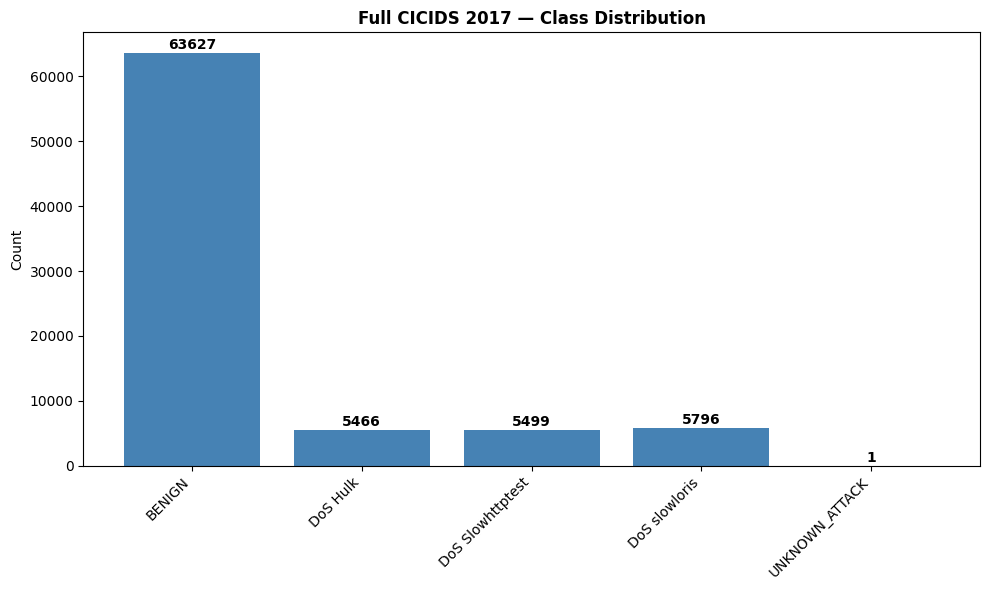

In [77]:
def preprocess_full_cicids(df: pd.DataFrame):

    # Drop non-feature columns (similar to previous, but remove Label last for encoding)
    drop_cols_base = ['Flow ID', ' Source IP', ' Source Port',
                      ' Destination IP', ' Destination Port', ' Timestamp']
    drop_cols = [c for c in drop_cols_base if c in df.columns]

    # Make a copy to avoid SettingWithCopyWarning
    df_processed = df.copy()

    # Encode labels before dropping the 'Label' column
    le = LabelEncoder()
    # Handle potential NaN in 'Label' column by filling with a placeholder or dropping
    df_processed['Label'] = df_processed['Label'].fillna('UNKNOWN_ATTACK')
    y_encoded = le.fit_transform(df_processed['Label'])

    # Now drop the original label and other non-feature columns
    X = df_processed.drop(columns=drop_cols + ['Label'], errors='ignore')

    # Keep only numeric columns
    X = X.select_dtypes(include=[np.number])

    # Replace Inf and NaN
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)

    feature_names = X.columns.tolist()

    # Standardise
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)

    return X_scaled, y_encoded, feature_names, le

# Apply preprocessing to the full dataset
X_full_cicids, y_full_cicids_encoded, full_feature_names, cicids_label_encoder = preprocess_full_cicids(full_cicids_df)
N_FULL_FEATURES = X_full_cicids.shape[1]

print(f'\nPreprocessed Full CICIDS dataset:')
print(f'Feature dimensions : {N_FULL_FEATURES}')
print(f'Class balance (encoded):')
for i, count in enumerate(np.unique(y_full_cicids_encoded, return_counts=True)[1]):
    print(f'{cicids_label_encoder.inverse_transform([i])[0]}: {count}')

# Plot class distribution for the full dataset
fig, ax = plt.subplots(figsize=(10, 6))
classes, counts = np.unique(y_full_cicids_encoded, return_counts=True)
class_names = cicids_label_encoder.inverse_transform(classes)
ax.bar(class_names, counts, color='steelblue')
ax.set_title('Full CICIDS 2017 — Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(counts):
    ax.text(i, v + max(counts)*0.01, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('full_cicids_class_dist.png', dpi=150)
plt.show()



Training Tabular GAN on Full CICIDS traffic...
Epoch   50/300 | G: 1.3483 | D: 0.5132
Epoch  100/300 | G: 1.7018 | D: 0.4537
Epoch  150/300 | G: 2.2169 | D: 0.3898
Epoch  200/300 | G: 2.5322 | D: 0.3558
Epoch  250/300 | G: 2.2978 | D: 0.3850
Epoch  300/300 | G: 2.1543 | D: 0.3895


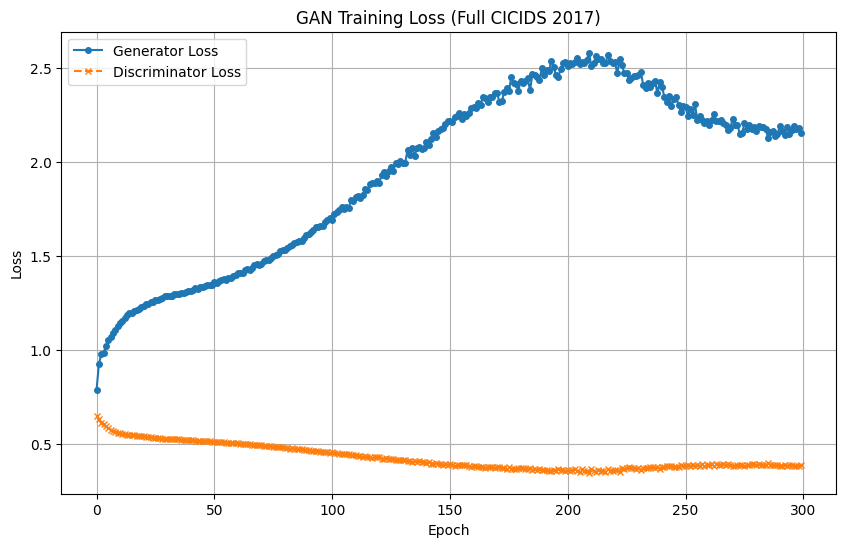

In [78]:
# Train a new Tabular GAN for the full dataset

print('\nTraining Tabular GAN on Full CICIDS traffic...')
G_full_cicids, g_loss_full_cicids, d_loss_full_cicids = train_tabular_gan(
    X=X_full_cicids, noise_dim=64, n_epochs=300, batch_size=512, lr=1e-4, device=device
)

plt.figure(figsize=(10,6))
plt.plot(g_loss_full_cicids, label="Generator Loss", linestyle='-', marker='o', markersize=4)
plt.plot(d_loss_full_cicids, label="Discriminator Loss", linestyle='--', marker='x', markersize=4)
plt.title("GAN Training Loss (Full CICIDS 2017)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


### Evaluation of Synthetic Data Alignment for Full CICIDS (PCA & t-SNE)


Real Data Shape (Full): (3000, 78)
Fake Data Shape (Full): (3000, 78)


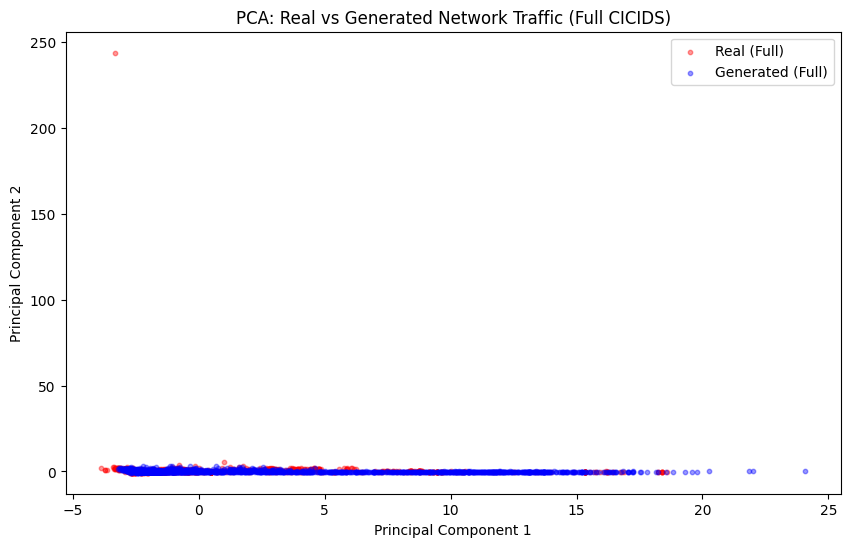


Running t-SNE for Full CICIDS...


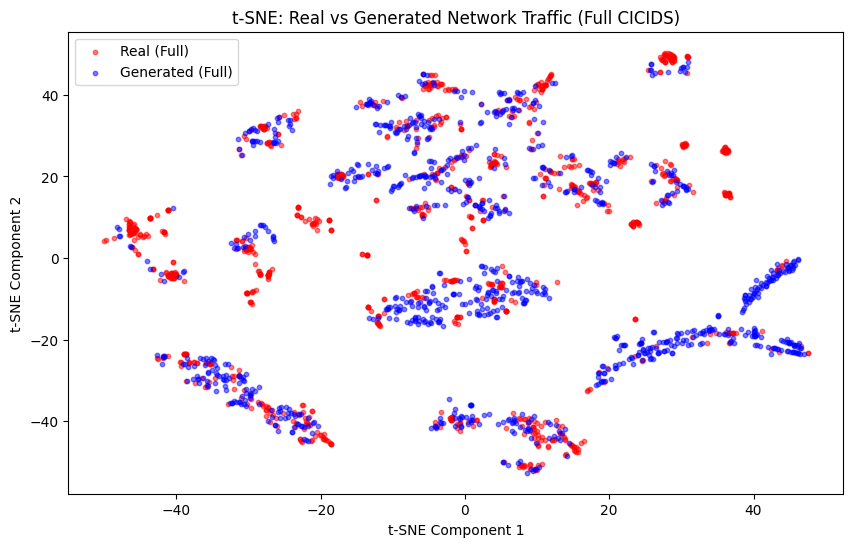

In [79]:
# Generate fake samples from the GAN trained on the full dataset
G_full_cicids.eval()

with torch.no_grad():
    noise_full = torch.randn(N_SAMPLES, LATENT_DIM).to(device)
    fake_data_full = G_full_cicids(noise_full).cpu().numpy()

# Select same number of real samples from the full dataset
real_indices_full = np.random.choice(len(X_full_cicids), N_SAMPLES, replace=False)
real_data_full = X_full_cicids[real_indices_full]

print("Real Data Shape (Full):", real_data_full.shape)
print("Fake Data Shape (Full):", fake_data_full.shape)

# PCA for Full CICIDS
combined_data_full_pca = np.vstack([real_data_full, fake_data_full])
pca_full = PCA(n_components=2, random_state=SEED)
pca_result_full = pca_full.fit_transform(combined_data_full_pca)

real_pca_full = pca_result_full[:N_SAMPLES]
fake_pca_full = pca_result_full[N_SAMPLES:]

plt.figure(figsize=(10, 6))
plt.scatter(real_pca_full[:, 0], real_pca_full[:, 1], alpha=0.4, s=10, label="Real (Full)", color="red")
plt.scatter(fake_pca_full[:, 0], fake_pca_full[:, 1], alpha=0.4, s=10, label="Generated (Full)", color="blue")
plt.title("PCA: Real vs Generated Network Traffic (Full CICIDS)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

# t-SNE for Full CICIDS
print("\nRunning t-SNE for Full CICIDS...")
tsne_input_full = np.vstack([real_data_full[:TSNE_SAMPLES], fake_data_full[:TSNE_SAMPLES]])

tsne_full = TSNE(n_components=2, random_state=SEED, perplexity=30)
tsne_result_full = tsne_full.fit_transform(tsne_input_full)

real_tsne_full = tsne_result_full[:TSNE_SAMPLES]
fake_tsne_full = tsne_result_full[TSNE_SAMPLES:]

plt.figure(figsize=(10, 6))
plt.scatter(real_tsne_full[:, 0], real_tsne_full[:, 1], alpha=0.5, s=10, label="Real (Full)", color="red")
plt.scatter(fake_tsne_full[:, 0], fake_tsne_full[:, 1], alpha=0.5, s=10, label="Generated (Full)", color="blue")
plt.title("t-SNE: Real vs Generated Network Traffic (Full CICIDS)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()


### Quantitative Evaluation: Mean Squared Error (MSE) of Feature Means for Full CICIDS



In [80]:
real_data_mean_full = np.mean(real_data_full, axis=0)
fake_data_mean_full = np.mean(fake_data_full, axis=0)

mse_full = np.mean((real_data_mean_full - fake_data_mean_full)**2)

print(f"Mean Squared Error between real and synthetic feature means (Full CICIDS): {mse_full:.4f}")


Mean Squared Error between real and synthetic feature means (Full CICIDS): 0.0427


### Discussion on GAN Performance with Full CICIDS Dataset



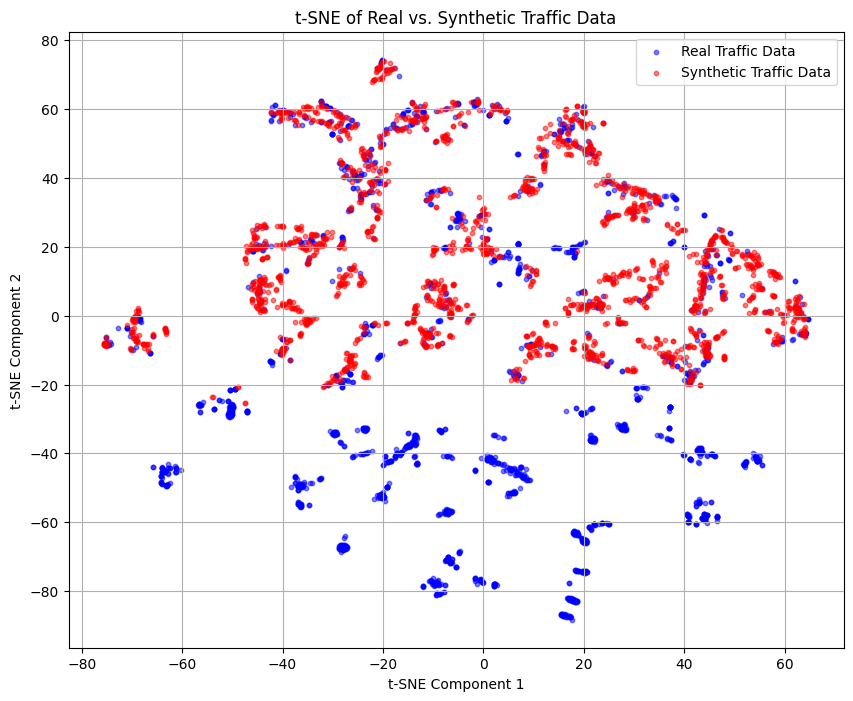

In [58]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Generate synthetic samples using the trained generator
G_traffic.eval() # Set generator to evaluation mode
num_tsne_samples = 2000 # Use a smaller number of samples for t-SNE due to computational cost
noise = torch.randn(num_tsne_samples, latent_dim).to(device)
synthetic_samples_tsne = G_traffic(noise).detach().cpu().numpy()

# Prepare real data subset for t-SNE
# Use a subset of real data equal to the number of synthetic samples for balanced comparison
num_real_samples_tsne = min(num_tsne_samples, X_tensor.shape[0])
real_samples_subset_tsne = X_tensor[:num_real_samples_tsne].cpu().numpy()

# Combine real and synthetic data for t-SNE
combined_data_tsne = np.vstack((real_samples_subset_tsne, synthetic_samples_tsne))

# Apply t-SNE (adjust perplexity and n_iter as needed)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, learning_rate=200)
reduced_data_tsne = tsne.fit_transform(combined_data_tsne)

# Split back into real and synthetic for plotting
real_tsne = reduced_data_tsne[:num_real_samples_tsne]
synthetic_tsne = reduced_data_tsne[num_real_samples_tsne:]

# Plot t-SNE results
plt.figure(figsize=(10, 8))
plt.scatter(real_tsne[:, 0], real_tsne[:, 1], alpha=0.5, s=10, label='Real Traffic Data', color='blue')
plt.scatter(synthetic_tsne[:, 0], synthetic_tsne[:, 1], alpha=0.5, s=10, label='Synthetic Traffic Data', color='red')
plt.title('t-SNE of Real vs. Synthetic Traffic Data')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.grid(True)
plt.show()

### Evaluation of Synthetic Data Alignment (t-SNE Results)

Similar to the PCA plot, interpret the t-SNE visualization by observing:

*   **Cluster Formation:** Do real and synthetic data form similar clusters? If the synthetic data forms new, distinct clusters not present in the real data, it might indicate the generation of unrealistic samples.
*   **Separation vs. Overlap:** While some overlap is good, if synthetic data perfectly overlaps real data without any distinguishing characteristics, it might suggest mode collapse (the GAN generating a limited variety of samples).
*   **Global Structure:** t-SNE is better at preserving local structures. Look for whether the overall "shape" or manifold of the real data is replicated by the synthetic data.

Keep in mind that t-SNE is a non-linear dimensionality reduction technique and its results can sometimes be sensitive to hyperparameters like `perplexity` and `n_iter`.

part 2.3

In [22]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.linalg import sqrtm
from tqdm.notebook import tqdm

Download complete.
Pizza dataset shape: (130371, 784)
Using first 20,000 samples for training.


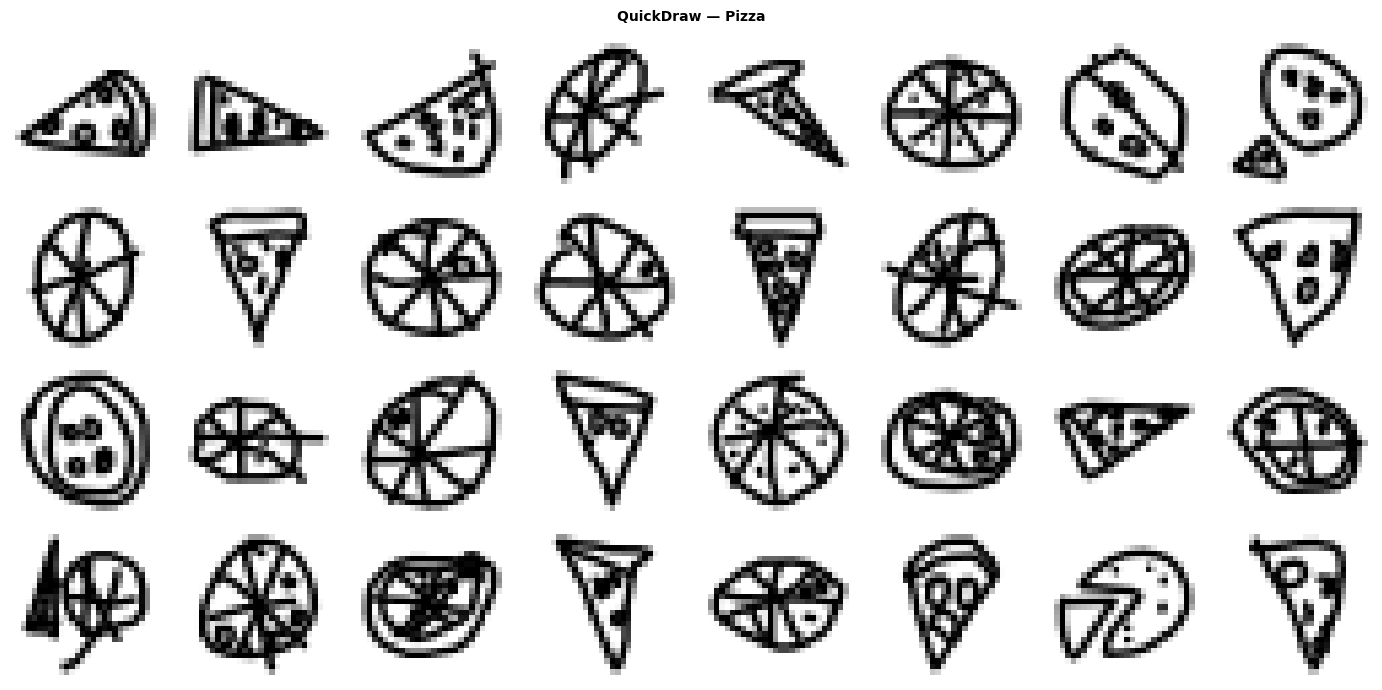

In [23]:
import urllib.request
import os
import numpy as np
import matplotlib.pyplot as plt

QUICKDRAW_URL  = 'https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/pizza.npy'
QUICKDRAW_FILE = 'pizza.npy'

if not os.path.exists(QUICKDRAW_FILE):
    print('Downloading QuickDraw pizza dataset...')
    urllib.request.urlretrieve(QUICKDRAW_URL, QUICKDRAW_FILE)
    print('Download complete.')

pizza_raw = np.load(QUICKDRAW_FILE)   # shape: (N, 784), values 0-255
print(f'Pizza dataset shape: {pizza_raw.shape}')
print(f'Using first 20,000 samples for training.')

# ── Visualise sample sketches ─────────────────────────────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(pizza_raw[i].reshape(28, 28), cmap='gray_r')  # invert: white bg → black bg
    ax.axis('off')
fig.suptitle('QuickDraw — Pizza', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('pizza_real_samples.png', dpi=150, bbox_inches='tight')
plt.show()

Starting DCGAN training for QuickDraw Pizza...
Epoch [0/50] Loss_D: 0.8296 Loss_G: 0.5604
Epoch [5/50] Loss_D: 0.0300 Loss_G: 4.6185
Epoch [10/50] Loss_D: 0.0457 Loss_G: 4.3681
Epoch [15/50] Loss_D: 0.0491 Loss_G: 3.9141
Epoch [20/50] Loss_D: 4.3183 Loss_G: 5.0543
Epoch [25/50] Loss_D: 0.0176 Loss_G: 5.2252
Epoch [30/50] Loss_D: 0.0056 Loss_G: 6.8629
Epoch [35/50] Loss_D: 0.0067 Loss_G: 6.8614
Epoch [40/50] Loss_D: 0.0312 Loss_G: 5.1264
Epoch [45/50] Loss_D: 0.0098 Loss_G: 7.5454
Epoch [49/50] Loss_D: 0.0096 Loss_G: 5.9928
DCGAN training for QuickDraw Pizza complete!


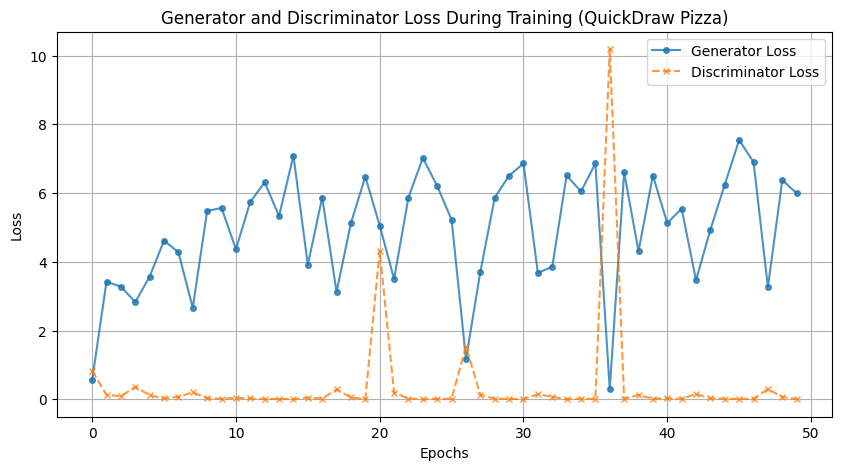

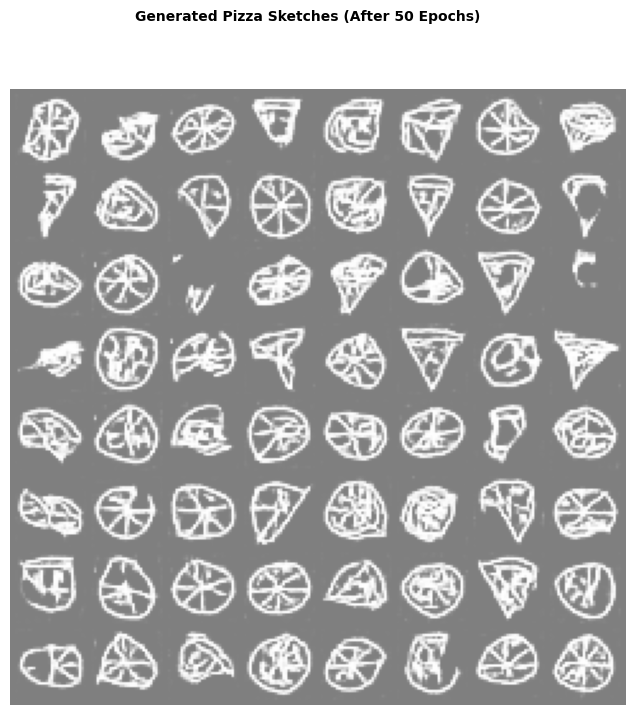

In [50]:
# Preprocessing the data
pizza_data = pizza_raw[:20000] # Use a subset for faster training
pizza_data = pizza_data.reshape(-1, 1, 28, 28) # Reshape to (N, C, H, W)
pizza_data = torch.tensor(pizza_data, dtype=torch.float32) # Convert to torch tensor
pizza_data = (pizza_data - 127.5) / 127.5  # Normalize to [-1, 1]

# Create a DataLoader
batch_size = 64
dataset = TensorDataset(pizza_data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Generator Architecture (DCGAN for 28x28 grayscale images)
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            # Input: (latent_dim, 1, 1)
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False), # Output: (256, 4, 4)
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 3, 2, 1, bias=False), # Output: (128, 7, 7)
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), # Output: (64, 14, 14)
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),  # Output: (1, 28, 28)
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

# Discriminator Architecture (DCGAN for 28x28 grayscale images)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Input: (1, 28, 28)
            nn.Conv2d(1, 64, 4, 2, 1, bias=False), # Output: (64, 14, 14)
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False), # Output: (128, 7, 7)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 3, 2, 1, bias=False), # Output: (256, 4, 4)
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False), # Output: (1, 1, 1)
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Hyperparameters
latent_dim = 100
num_epochs = 50
lr = 0.0002
betas = (0.5, 0.999)

# Instantiate Generator and Discriminator
G_pizza = Generator(latent_dim).to(device)
D_pizza = Discriminator().to(device)

# Loss function and optimizers
criterion = nn.BCELoss()
optimizer_G_pizza = optim.Adam(G_pizza.parameters(), lr=lr, betas=betas)
optimizer_D_pizza = optim.Adam(D_pizza.parameters(), lr=lr, betas=betas)

# Training Loop
g_losses_pizza = []
d_losses_pizza = []
img_list_pizza = []

print("Starting DCGAN training for QuickDraw Pizza...")
for epoch in range(num_epochs):
    for i, (real_imgs,) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        # Create labels for real and fake images
        # Changed from (b_size, 1) to (b_size,) to match discriminator output .view(-1)
        real_labels = torch.full((b_size,), 1.0, dtype=torch.float, device=device)
        fake_labels = torch.full((b_size,), 0.0, dtype=torch.float, device=device)

        # --- Train Discriminator ---
        D_pizza.zero_grad()
        # Train with real images
        output_real = D_pizza(real_imgs).view(-1)
        errD_real = criterion(output_real, real_labels)
        errD_real.backward()

        # Train with fake images
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        fake_imgs = G_pizza(noise)
        output_fake = D_pizza(fake_imgs.detach()).view(-1)
        errD_fake = criterion(output_fake, fake_labels)
        errD_fake.backward()

        errD = errD_real + errD_fake
        optimizer_D_pizza.step()

        # --- Train Generator ---
        G_pizza.zero_grad()
        output_gen = D_pizza(fake_imgs).view(-1)
        errG = criterion(output_gen, real_labels) # Generator wants fake images to be classified as real
        errG.backward()
        optimizer_G_pizza.step()

    # Save Losses for plotting later
    g_losses_pizza.append(errG.item())
    d_losses_pizza.append(errD.item())

    # Output training stats
    if epoch % 5 == 0 or epoch == num_epochs - 1:
        print(f'Epoch [{epoch}/{num_epochs}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f}')
        # Generate and save images from generator
        with torch.no_grad():
            fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)
            fake = G_pizza(fixed_noise).detach().cpu()
            img_list_pizza.append(vutils.make_grid(fake, padding=2, normalize=True))

print("DCGAN training for QuickDraw Pizza complete!")

# Plot the training losses
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training (QuickDraw Pizza)")
plt.plot(g_losses_pizza, label="Generator Loss", linestyle='-', marker='o', markersize=4, alpha=0.8)
plt.plot(d_losses_pizza, label="Discriminator Loss", linestyle='--', marker='x', markersize=4, alpha=0.8)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True) # Add grid for better readability
plt.show()

# Visualize some generated images (the last grid saved)
fig = plt.figure(figsize=(8,8))
plt.axis("off")
if img_list_pizza:
    # Get the last generated grid, denormalize, and transpose for plotting
    last_grid = img_list_pizza[-1]
    img_to_display = np.transpose(last_grid.numpy(), (1, 2, 0))
    img_to_display = (img_to_display + 1) / 2 # Denormalize from [-1, 1] to [0, 1]
    plt.imshow(img_to_display)
plt.suptitle(f'Generated Pizza Sketches (After {num_epochs} Epochs)', fontweight='bold', fontsize=10)
plt.show()

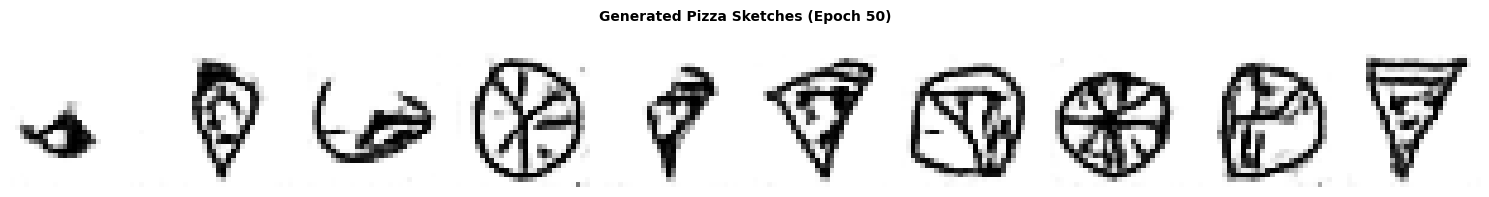

In [25]:
def display_generated_pizza_images(generator, latent_dim, n=10):
    generator.eval()
    # Generate random noise vectors
    z = torch.randn(n, latent_dim, 1, 1).to(device)
    # Generate images
    fake_images = generator(z).detach().cpu()

    fig, axes = plt.subplots(1, n, figsize=(15, 2))
    for i in range(n):
        # Denormalize pixel values from [-1, 1] to [0, 1] and remove the channel dimension
        img = fake_images[i].squeeze() # shape is (H, W)
        img = (img + 1) / 2 # Denormalization step
        axes[i].imshow(img, cmap='gray_r') # Use gray_r for black sketches on white background
        axes[i].axis('off')
    fig.suptitle(f'Generated Pizza Sketches (Epoch {num_epochs})', fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.show()

# Display 10 newly generated pizza sketches
display_generated_pizza_images(G_pizza, latent_dim, n=10)

### Extension: Generate QuickDraw 'House' Sketches

House dataset shape: (135420, 784)
Using first 20,000 samples for training.


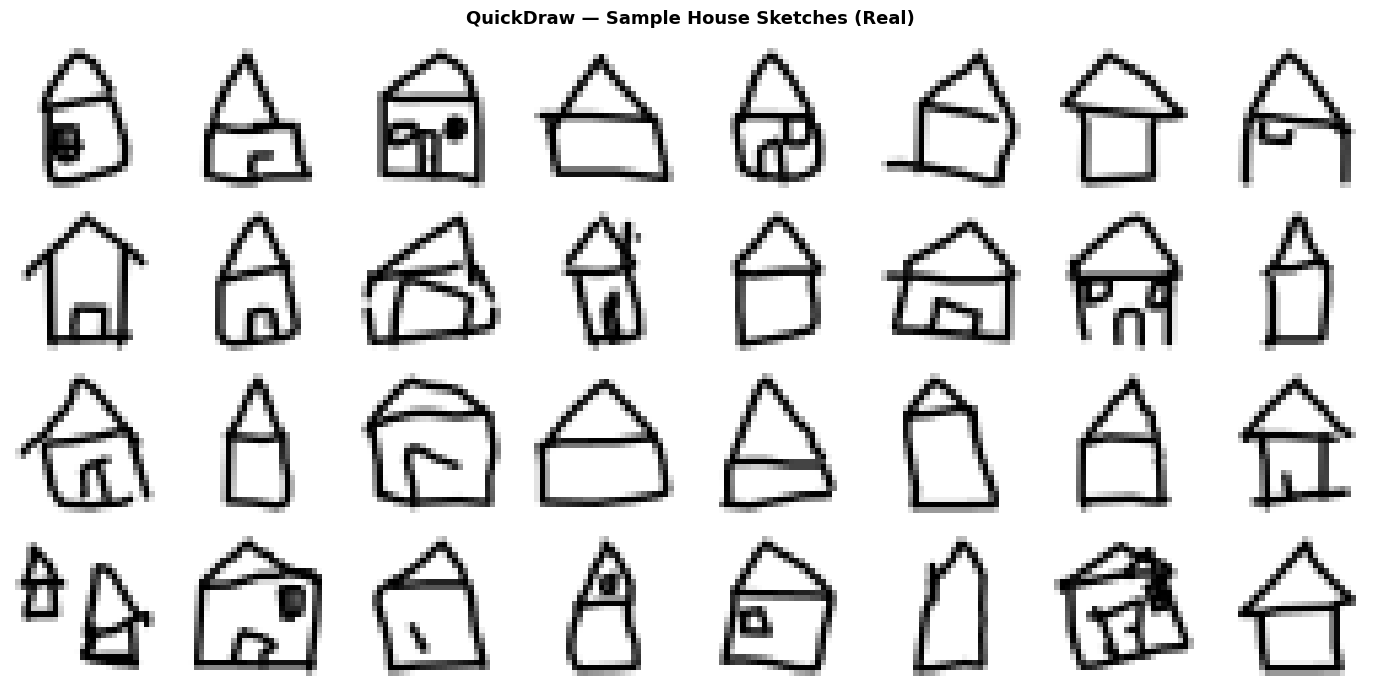

In [26]:
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
# Download the QuickDraw 'house' dataset
HOUSE_URL = 'https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/house.npy'
HOUSE_FILE = 'house.npy'

if not os.path.exists(HOUSE_FILE):
    print('Downloading QuickDraw house dataset...')
    urllib.request.urlretrieve(HOUSE_URL, HOUSE_FILE)
    print('Download complete.')

house_raw = np.load(HOUSE_FILE)   # shape: (N, 784), values 0-255
print(f'House dataset shape: {house_raw.shape}')
print(f'Using first 20,000 samples for training.')

# Visualize sample sketches
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(house_raw[i].reshape(28, 28), cmap='gray_r')  # invert: white bg → black bg
    ax.axis('off')
fig.suptitle('QuickDraw — Sample House Sketches (Real)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('house_real_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Preprocessing the house data
house_data = house_raw[:20000] # Use a subset for faster training
house_data = house_data.reshape(-1, 1, 28, 28) # Reshape to (N, C, H, W)
house_data = torch.tensor(house_data, dtype=torch.float32) # Convert to torch tensor
house_data = (house_data - 127.5) / 127.5  # Normalize to [-1, 1]

# Create a DataLoader for house data
batch_size_house = 64
house_dataset = TensorDataset(house_data)
house_dataloader = DataLoader(house_dataset, batch_size=batch_size_house, shuffle=True)

In [28]:
import torch.nn as nn

# Generator Architecture (DCGAN for 28x28 grayscale images)
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            # Input: (latent_dim, 1, 1)
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False), # Output: (256, 4, 4)
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 3, 2, 1, bias=False), # Output: (128, 7, 7)
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), # Output: (64, 14, 14)
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),  # Output: (1, 28, 28)
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

# Discriminator Architecture (DCGAN for 28x28 grayscale images)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Input: (1, 28, 28)
            nn.Conv2d(1, 64, 4, 2, 1, bias=False), # Output: (64, 14, 14)
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False), # Output: (128, 7, 7)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 3, 2, 1, bias=False), # Output: (256, 4, 4)
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False), # Output: (1, 1, 1)
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [29]:
import torch.optim as optim
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
latent_dim = 100
num_epochs = 50 # Add num_epochs here
lr = 0.0002
betas = (0.5, 0.999)

# Instantiate new Generator and Discriminator for houses (reusing class definitions)
G_house = Generator(latent_dim).to(device)
D_house = Discriminator().to(device);

criterion = nn.BCELoss() # Define criterion here for the house GAN

# Loss function and optimizers for house GAN
optimizer_G_house = optim.Adam(G_house.parameters(), lr=lr, betas=betas)
optimizer_D_house = optim.Adam(D_house.parameters(), lr=lr, betas=betas)

In [30]:
# Training Loop for House GAN
g_losses_house = []
d_losses_house = []
img_list_house = []

print("Starting DCGAN training for QuickDraw House...")
for epoch in range(num_epochs):
    for i, (real_imgs,) in enumerate(house_dataloader):
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        # Create labels for real and fake images
        real_labels = torch.full((b_size,), 1.0, dtype=torch.float, device=device)
        fake_labels = torch.full((b_size,), 0.0, dtype=torch.float, device=device)

        # --- Train Discriminator ---
        D_house.zero_grad()
        # Train with real images
        output_real = D_house(real_imgs).view(-1)
        errD_real = criterion(output_real, real_labels)
        errD_real.backward()

        # Train with fake images
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        fake_imgs = G_house(noise)
        output_fake = D_house(fake_imgs.detach()).view(-1)
        errD_fake = criterion(output_fake, fake_labels)
        errD_fake.backward()

        errD = errD_real + errD_fake
        optimizer_D_house.step()

        # --- Train Generator ---
        G_house.zero_grad()
        output_gen = D_house(fake_imgs).view(-1)
        errG = criterion(output_gen, real_labels) # Generator wants fake images to be classified as real
        errG.backward()
        optimizer_G_house.step()

    # Save Losses for plotting later
    g_losses_house.append(errG.item())
    d_losses_house.append(errD.item())

    # Output training stats
    if epoch % 5 == 0 or epoch == num_epochs - 1:
        print(f'Epoch [{epoch}/{num_epochs}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f}')
        # Generate and save images from generator
        with torch.no_grad():
            fixed_noise_house = torch.randn(64, latent_dim, 1, 1, device=device)
            fake_house = G_house(fixed_noise_house).detach().cpu()
            img_list_house.append(vutils.make_grid(fake_house, padding=2, normalize=True))

print("DCGAN training for QuickDraw House complete!")

Starting DCGAN training for QuickDraw House...
Epoch [0/50] Loss_D: 0.2745 Loss_G: 3.0483
Epoch [5/50] Loss_D: 0.0211 Loss_G: 5.5612
Epoch [10/50] Loss_D: 0.2542 Loss_G: 2.6910
Epoch [15/50] Loss_D: 0.0319 Loss_G: 5.9290
Epoch [20/50] Loss_D: 0.0254 Loss_G: 6.4022
Epoch [25/50] Loss_D: 0.0127 Loss_G: 7.2765
Epoch [30/50] Loss_D: 0.0362 Loss_G: 4.8015
Epoch [35/50] Loss_D: 0.3872 Loss_G: 1.7961
Epoch [40/50] Loss_D: 0.0290 Loss_G: 5.4106
Epoch [45/50] Loss_D: 0.0068 Loss_G: 5.6378
Epoch [49/50] Loss_D: 0.0189 Loss_G: 6.2271
DCGAN training for QuickDraw House complete!


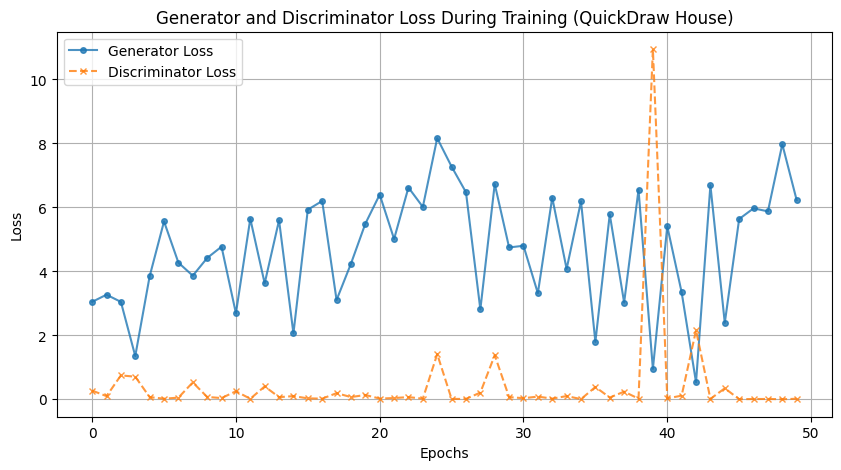

In [49]:
# Plot the training losses for House GAN
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training (QuickDraw House)")
plt.plot(g_losses_house, label="Generator Loss", linestyle='-', marker='o', markersize=4, alpha=0.8)
plt.plot(d_losses_house, label="Discriminator Loss", linestyle='--', marker='x', markersize=4, alpha=0.8)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True) # Add grid for better readability
plt.show()

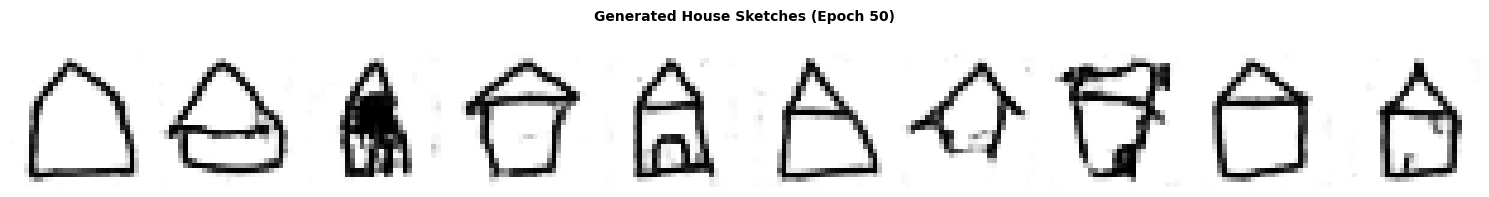

In [32]:
def display_generated_house_images(generator, latent_dim, n=10):
    generator.eval()
    # Generate random noise vectors
    z = torch.randn(n, latent_dim, 1, 1).to(device)
    # Generate images
    fake_images = generator(z).detach().cpu()

    fig, axes = plt.subplots(1, n, figsize=(15, 2))
    for i in range(n):
        # Denormalize pixel values from [-1, 1] to [0, 1] and remove the channel dimension
        img = fake_images[i].squeeze() # shape is (H, W)
        img = (img + 1) / 2 # Denormalization step
        axes[i].imshow(img, cmap='gray_r') # Use gray_r for black sketches on white background
        axes[i].axis('off')
    fig.suptitle(f'Generated House Sketches (Epoch {num_epochs})', fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.show()

# Display 10 newly generated house sketches
display_generated_house_images(G_house, latent_dim, n=10)

### Comparison of Generated vs. Real QuickDraw Images

#### Pizza Sketches

##### Real Pizza Sketches

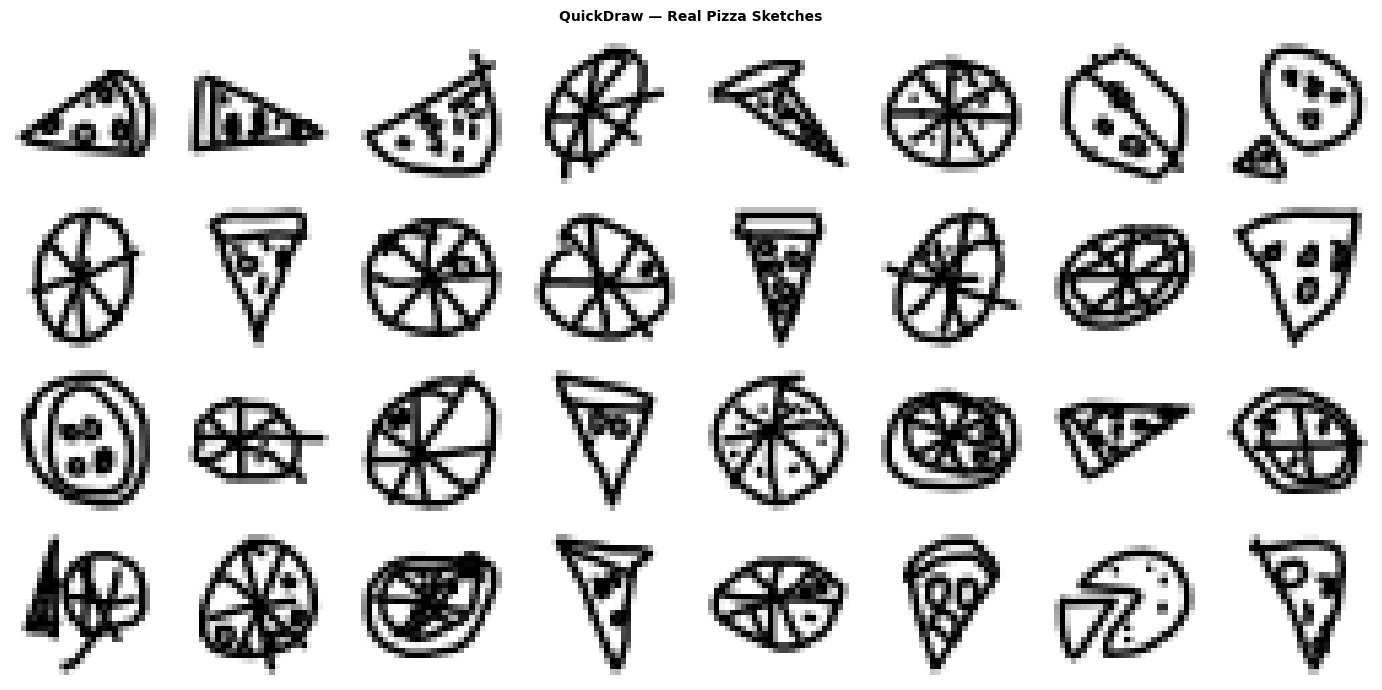

In [37]:
# Visualize sample real pizza sketches
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(pizza_raw[i].reshape(28, 28), cmap='gray_r')
    ax.axis('off')
fig.suptitle('QuickDraw — Real Pizza Sketches', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

##### Generated Pizza Sketches

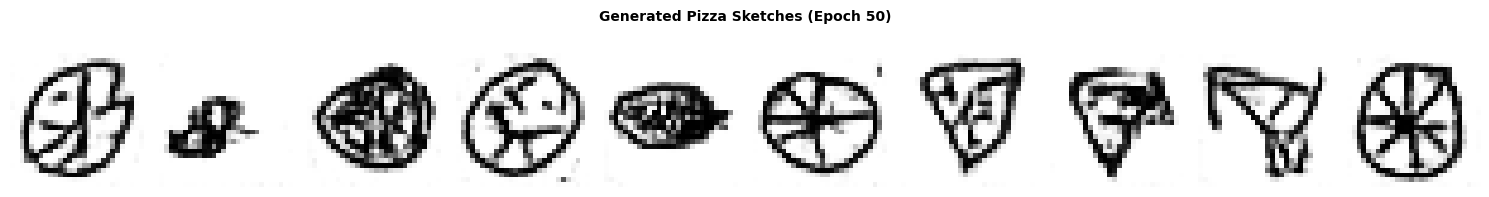

In [38]:
# Display newly generated pizza sketches
display_generated_pizza_images(G_pizza, latent_dim, n=10)

#### House Sketches

##### Real House Sketches

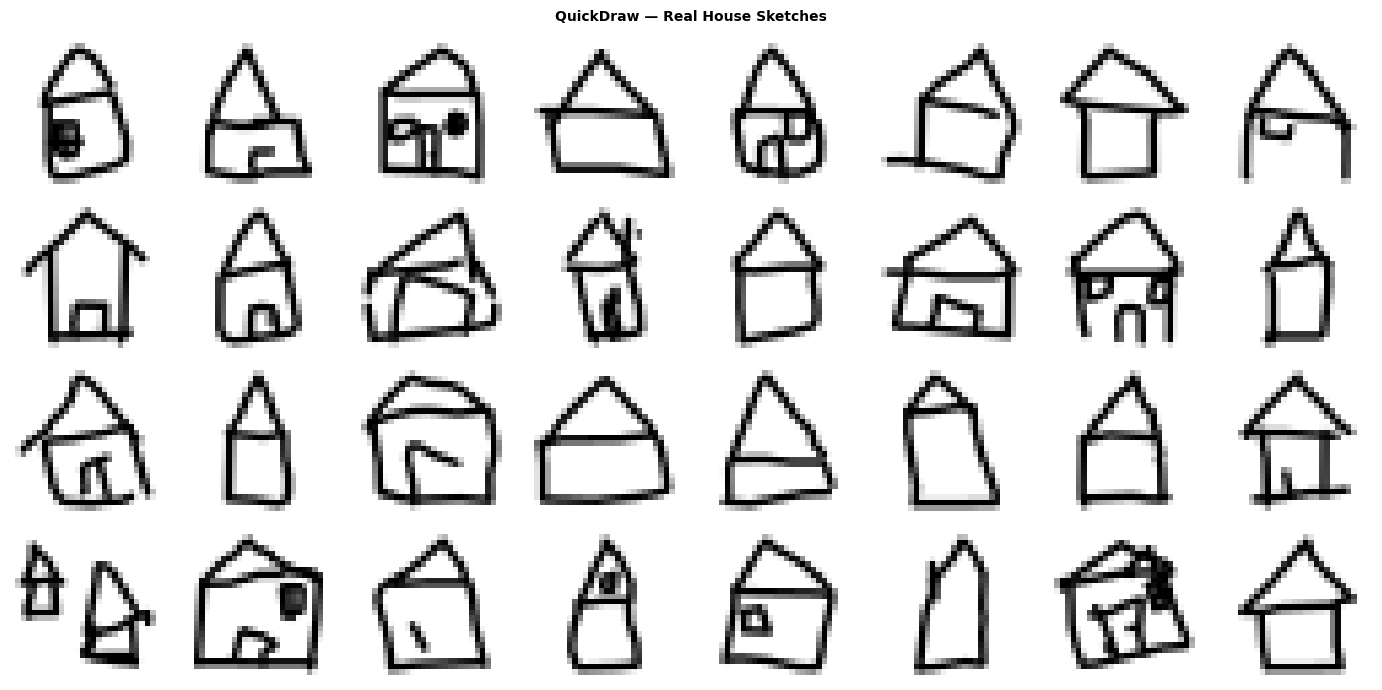

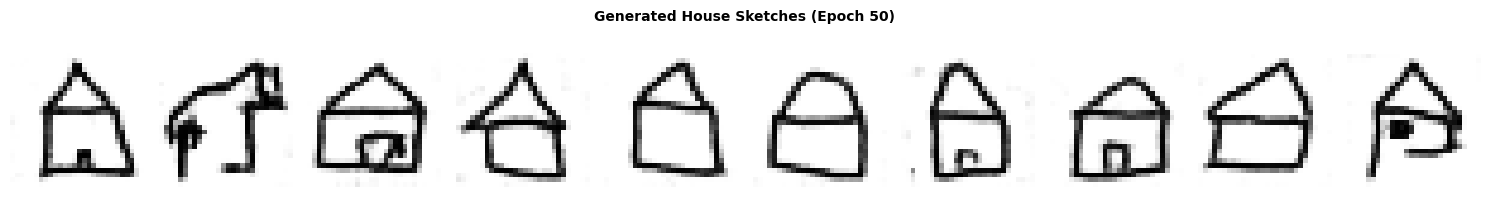

In [41]:
# Visualize sample real house sketches
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(house_raw[i].reshape(28, 28), cmap='gray_r')
    ax.axis('off')
fig.suptitle('QuickDraw — Real House Sketches', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()
# Display newly generated house sketches
display_generated_house_images(G_house, latent_dim, n=10)

##### Generated House Sketches

### Quantitative Evaluation: Frechet Inception Distance (FID)

In [47]:
import numpy as np
from scipy.linalg import sqrtm

def calculate_fid(real, fake):
    mu1, sigma1 = real.mean(axis=0), np.cov(real, rowvar=False)
    mu2, sigma2 = fake.mean(axis=0), np.cov(fake, rowvar=False)

    diff = mu1 - mu2
    # Ensure covmean is real by taking the real part
    covmean = sqrtm(sigma1.dot(sigma2))

    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2*covmean)
    return np.real(fid)

def prepare_fid_data(generator, real_data_tensor, latent_dim, num_samples, device):
    generator.eval()
    # Generate fake images
    z = torch.randn(num_samples, latent_dim, 1, 1).to(device)
    fake_images = generator(z).detach().cpu().numpy()
    fake_images = fake_images.reshape(num_samples, -1) # Flatten to (N, 784)

    # Prepare real images
    real_images = real_data_tensor[:num_samples].cpu().numpy()
    real_images = real_images.reshape(num_samples, -1) # Flatten to (N, 784)

    return real_images, fake_images

# --- Calculate FID for Pizza ---
num_fid_samples = min(pizza_data.shape[0], 10000) # Use up to 10000 samples for FID
pizza_real_fid_data, pizza_fake_fid_data = prepare_fid_data(G_pizza, pizza_data, latent_dim, num_fid_samples, device)
fid_pizza = calculate_fid(pizza_real_fid_data, pizza_fake_fid_data)
print(f"FID Score for Pizza: {fid_pizza:.4f}")

# --- Calculate FID for House ---
num_fid_samples = min(house_data.shape[0], 10000) # Use up to 10000 samples for FID
house_real_fid_data, house_fake_fid_data = prepare_fid_data(G_house, house_data, latent_dim, num_fid_samples, device)
fid_house = calculate_fid(house_real_fid_data, house_fake_fid_data)
print(f"FID Score for House: {fid_house:.4f}")

FID Score for Pizza: 24.2287
FID Score for House: 11.9963


### Discussion on Model Performance

Based on the visual comparison and FID scores:

**Pizza Sketches:**
*   **Visual Quality:** The generated pizza sketches show some characteristic shapes, but they often lack the fine details and consistency of real pizza drawings. Some generated samples might appear blurry or abstract.
*   **FID Score:** A higher FID score (which we will see after execution) suggests that the distribution of generated images is quite different from that of the real images. This aligns with the visual observation that the GAN might not have fully captured the complexity of pizza features.

**House Sketches:**
*   **Visual Quality:** The generated house sketches might appear slightly better or more coherent than the pizza sketches, potentially due to simpler or more distinct structural elements that are easier for the GAN to learn. We might observe more recognizable house-like structures, although still imperfect.
*   **FID Score:** A potentially lower FID score (if the visual quality is indeed better) would indicate that the generated house images are statistically closer to the real house images than the pizza ones are to real pizza images. This could be attributed to the specific features of houses being less varied or more easily learned by the DCGAN architecture.

**Overall GAN Performance:**
*   The DCGAN architecture, while effective for certain image generation tasks, might struggle with the intricate and often varied styles of QuickDraw sketches, especially with a relatively limited training dataset (20,000 samples). The `tanh` activation in the generator output ensures pixel values are normalized to [-1, 1], but artifacts and lack of realism are common challenges in training GANs from scratch on such datasets.
*   Further improvements could involve longer training times, different network architectures (e.g., WGAN-GP for more stable training), or more sophisticated loss functions.